#RQ3 -  Do male and female participants differ in line-level reading behaviour during code comprehension? (Are there any gender differences in line-level reading patterns of code, such as line dwell time, time to first fixation, revisits and coverage?)

RQ2 examined whether male and female participants differ in overall process-level cognitive effort during code comprehension, as reflected in global eye-tracking and behavioural timing measures.

RQ3 extends that analysis from aggregate participant-task measures to line-level reading behaviour. It asks whether male and female participants differ in when individual source-code lines are first fixated, how much line dwell time is allocated to each line, whether lines are revisited, and whether lines are covered at least once.

This line-level analysis helps distinguish a difference in fixation intensity from a difference in reading organisation.

# Mount and import

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers')

In [3]:
import parsers
import aoi
import visualization
import util

In [4]:
import os
import pandas as pd
import numpy as np

In [5]:
DATA_LOSS_THRESHOLD = 70.0

In [6]:
RAWDATA = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/rawdata"

# Testing for Validity Column in raw samples


In [7]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [8]:
def process_batch(batch, invalid_values):
    """Process a batch of TSV lines, extracting timestamp + R Validity safely."""
    valid_lines = 0
    invalid_lines = 0
    for line in batch:
        cols = line.split("\t")

        # We ONLY care about SMP rows
        if len(cols) < 2:
            continue
        if cols[1] != "SMP":
            continue

        # Check timestamp exists
        timestamp = cols[0].strip() if len(cols) > 0 else None

        # Safely extract R Validity (col 27)
        if len(cols) > 27:
            r_validity = cols[27].strip()
        else:
            # Missing R validity â€” treat as invalid
            r_validity = "MISSING"

        # Check if invalid
        if r_validity not in ("0", "1"):
            invalid_values.add(r_validity)
        else:
          if r_validity == "1":
            valid_lines += 1
          else:
            invalid_lines += 1

    return valid_lines, invalid_lines


In [9]:

# Global counters
files_all_valid = 0
files_with_invalid = 0


def check_validity_in_batches(tsv_path, batch_size=10):
    """
    Stream-reads a TSV file in small batches.
    Extracts timestamp + R-validity only from SMP rows.
    Tracks invalid R-validity values.
    """
    global files_all_valid, files_with_invalid


    print(f"\nChecking file: {os.path.basename(tsv_path)}")

    invalid_values = set()
    total_lines = 0
    total_valid_lines = 0
    total_invalid_lines =0
    participant_id = os.path.basename(tsv_path).split("_")[0]
    batch = []


    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            total_lines += 1

            if not line.strip():
                continue

            batch.append(line)

            if len(batch) >= batch_size:
                valid_lines, invalid_lines = process_batch(batch, invalid_values)
                total_valid_lines += valid_lines
                total_invalid_lines += invalid_lines
                batch = []

        # last partial batch
        if batch:
            process_batch(batch, invalid_values)

    # ---- Summary for THIS file ----
    if invalid_values:
        print(f" Invalid R Validity values: {invalid_values}")
        files_with_invalid += 1
    else:
        print(f" All R Validity values are 0 or 1.")
        files_all_valid += 1

    print(f"Processed {total_lines} lines.")
    print(f"Valid lines: {total_valid_lines}")
    print(f"Invalid lines: {total_invalid_lines}")
    percentage_valid = (total_valid_lines / total_lines) * 100
    print(f"Percentage of valid lines: {percentage_valid}")
    if percentage_valid >= DATA_LOSS_THRESHOLD:
      valid_participants.add(participant_id)



In [10]:

global valid_participants
valid_participants = set()
for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
           check_validity_in_batches(os.path.join(root, fname), batch_size=10)


# ---------------------------
# FINAL GLOBAL SUMMARY
# ---------------------------
print("\n====================++====SUMMARY=====++======================")
print(f"Files with ONLY R-validity values (0 or 1):  {files_all_valid}")
print(f"Files with R-validity values other than 0/1: {files_with_invalid}")
print(f"Valid participants: {valid_participants}")
print(f"Total valid participants: {len(valid_participants)}")
print("=================================================================\n")



Checking file: 99_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49759 lines.
Valid lines: 48848
Invalid lines: 853
Percentage of valid lines: 98.16917542555116

Checking file: 96_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 47777 lines.
Valid lines: 40753
Invalid lines: 6968
Percentage of valid lines: 85.29836532222618

Checking file: 97_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 49360 lines.
Valid lines: 48757
Invalid lines: 554
Percentage of valid lines: 98.77836304700162

Checking file: 91_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 34786 lines.
Valid lines: 32957
Invalid lines: 1774
Percentage of valid lines: 94.74213764157994

Checking file: 85_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 37146 lines.
Valid lines: 35745
Invalid lines: 1351
Percentage of valid lines: 96.22839605879503

Checking file: 9_rawdata.tsv
 All R Validity values are 0 or 1.
Processed 48338 lines.
Valid lines: 33281
Invalid lines: 15005
Percentag

# Trackability threshold


In [11]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [12]:
def check_code_reading_validity(tsv_path):
    participant_id = os.path.basename(tsv_path).split("_")[0]

    in_code_section = False
    total_samples = 0
    valid_samples = 0

    with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            cols = line.split("\t")
            if len(cols) < 2:
                continue

            row_type = cols[1].strip()

            if row_type == "MSG":
                if len(cols) > 3:
                    raw = cols[3].strip()
                    stimulus = cols[3].split(' ')[-1]
                    if stimulus.startswith("vehicle") or stimulus.startswith("rectangle"):
                        in_code_section = True
                    else:
                        in_code_section = False

            elif row_type == "SMP" and in_code_section:
                total_samples += 1
                r_validity = cols[27].strip() if len(cols) > 27 else None
                if r_validity == "1":
                    valid_samples += 1

    if total_samples == 0:
        print(f"[{participant_id}] No SMP samples found during code-reading sections.")
        return participant_id, None

    pct_valid = (valid_samples / total_samples) * 100
    print(f"[{participant_id}] Code-reading samples: {total_samples} | "
          f"Valid: {valid_samples} | {pct_valid:.1f}%")
    return participant_id, pct_valid




In [13]:
# â”€â”€ Run â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

results = {}

for root, dirs, files in os.walk(RAWDATA):
    for fname in files:
        if fname.endswith(".tsv") and fname[0].isdigit():
            pid, pct = check_code_reading_validity(os.path.join(root, fname))
            results[pid] = pct

# â”€â”€ Summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

trackable_participants = {pid for pid, pct in results.items()
                      if pct is not None and pct >= DATA_LOSS_THRESHOLD}

print("\n==================== SUMMARY ====================")
for pid, pct in sorted(results.items()):
    pct_str = f"{pct:.1f}%" if pct is not None else "N/A"
    print(f"  {pid}: {pct_str} valid during code reading")

print(f"\nValid participants (>= {DATA_LOSS_THRESHOLD}%): {len(trackable_participants)}")
print(f"Length of valid participants {len(trackable_participants)}")
print("==================================================\n")

[99] Code-reading samples: 27701 | Valid: 27334 | 98.7%
[96] Code-reading samples: 29419 | Valid: 28836 | 98.0%
[97] Code-reading samples: 27900 | Valid: 27675 | 99.2%
[91] Code-reading samples: 23765 | Valid: 22585 | 95.0%
[85] Code-reading samples: 24250 | Valid: 23215 | 95.7%
[9] Code-reading samples: 27806 | Valid: 16529 | 59.4%
[94] Code-reading samples: 19357 | Valid: 19025 | 98.3%
[93] Code-reading samples: 9420 | Valid: 8383 | 89.0%
[87] Code-reading samples: 30532 | Valid: 27100 | 88.8%
[90] Code-reading samples: 8674 | Valid: 8478 | 97.7%
[83] Code-reading samples: 38912 | Valid: 37522 | 96.4%
[8] Code-reading samples: 50358 | Valid: 43460 | 86.3%
[74] Code-reading samples: 14902 | Valid: 13351 | 89.6%
[88] Code-reading samples: 29053 | Valid: 27327 | 94.1%
[84] Code-reading samples: 36312 | Valid: 32235 | 88.8%
[98] Code-reading samples: 18734 | Valid: 7431 | 39.7%
[81] Code-reading samples: 26643 | Valid: 26399 | 99.1%
[76] Code-reading samples: 32269 | Valid: 28903 | 89.6%

In [14]:
print(f"Number of participants in valid_participants: {len(valid_participants)}")
print(f"Number of participants in trackable_participants: {len(trackable_participants)}")

# Find common participants
common_participants = valid_participants.intersection(trackable_participants)
print(f"\nCommon participants ({len(common_participants)}): {sorted(list(common_participants))}")

# Find participants in valid_participants but not in trackable_participants
valid_but_not_trackable = valid_participants.difference(trackable_participants)
if valid_but_not_trackable:
    print(f"\nParticipants in valid_participants but NOT in trackable_participants ({len(valid_but_not_trackable)}): {sorted(list(valid_but_not_trackable))}")
else:
    print("\nAll participants in valid_participants are also in trackable_participants.")

# Find participants in trackable_participants but not in valid_participants
trackable_but_not_valid = trackable_participants.difference(valid_participants)
if trackable_but_not_valid:
    print(f"\nParticipants in trackable_participants but NOT in valid_participants ({len(trackable_but_not_valid)}): {sorted(list(trackable_but_not_valid))}")
else:
    print("\nAll participants in trackable_participants are also in valid_participants.")

# Check if sets are identical
if valid_participants == trackable_participants:
    print("\nThe sets valid_participants and trackable_participants are identical.")
else:
    print("\nThe sets valid_participants and trackable_participants are NOT identical.")

Number of participants in valid_participants: 187
Number of participants in trackable_participants: 188

Common participants (183): ['10', '100', '101', '105', '106', '107', '108', '109', '11', '110', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '126', '128', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '168', '169', '17', '170', '171', '172', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '2', '20', '200', '201', '202', '206', '207', '208', '21', '210', '211', '213', '214', '215', '216', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', 

# Load Participants

In [15]:
MAX_DISPERSION = 68
MINIMUM_DURATION = 100

First half of participants 1 - 108

In [16]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'
os.chdir(desired_path)

In [17]:
eye_events, samples, stimulus_time = parsers.EMIP(sample_size = 108,
                                                  process_raw_samples=False,
                                                  use_minus_one_for_invalid_gaze=False,
                                                  classifier="idt",
                                                  maximum_dispersion = MAX_DISPERSION,
                                                  minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Second half of participants 109 - 216

In [18]:
eye_events2, samples2, stimulus_time2 = parsers.EMIP(sample_size = 108,
                                                     start_index = 108,
                                                     process_raw_samples=False,
                                                     use_minus_one_for_invalid_gaze=False,
                                                     classifier="idt",
                                                     maximum_dispersion = MAX_DISPERSION,
                                                     minimum_duration = MINIMUM_DURATION)

Loaded metadata for 216 participants
Gender mapping created for 216 participants
Males: 175
Females: 41
Finished loading eye events for participants.


Combine the two batches of eye events

In [19]:
eye_events = pd.concat([eye_events, eye_events2])

In [20]:
eye_events.head()

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender
0,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,947809128,270.938,1532.046744,252.807907,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
1,SMIRed250,1,1,1_rawdata.tsv,0,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_calibration.jpg,948829995,119.831,813.900667,513.561000,"[1008043594, MSG, 1, # Message: instruction_co...",0,fixation,male
2,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008594653,188.028,990.360833,432.789583,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
3,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1008798679,95.991,925.132400,408.627200,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male
4,SMIRed250,1,1,1_rawdata.tsv,1,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,instruction_comprehension.jpg,1009110603,99.997,790.459231,285.858462,"[1020309277, MSG, 1, # Message: vehicle_java.jpg]",0,fixation,male


Merge samples if loaded

In [21]:
if samples and not samples.empty and samples2 and not samples2.empty:
    samples = pd.concat([samples, samples2])

In [22]:
if samples and not samples.empty:
  samples.head()
else:
  print("Raw samples not loaded")

Raw samples not loaded


In [23]:
#find unique participants and number of participants in data frame eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

Combine time spent on each stimulus




In [24]:
stimulus_time = pd.concat([stimulus_time, stimulus_time2])

In [25]:
display(stimulus_time)
display(len(stimulus_time))

,participant_id,gender,trial,stimulus_name,start_timestamp,end_timestamp,time_spenton_stimuli
0,1,male,0,instruction_calibration.jpg,945553890,952864364,7310474
1,1,male,1,instruction_comprehension.jpg,1008050652,1020308008,12257356
2,1,male,2,vehicle_java.jpg,1020312074,1097995373,77683299
3,1,male,3,mupliple_choice_vehicle.jpg,1097999372,1137882278,39882906
4,1,male,4,instruction_comprehension.jpg,1137916069,1145160532,7244463
...,...,...,...,...,...,...,...
751,216,female,2,vehicle_java2.jpg,406962816,481100215,74137399
752,216,female,3,mupliple_choice_vehicle.jpg,481116216,497818826,16702610
753,216,female,4,instruction_comprehension.jpg,497838818,502194738,4355920
754,216,female,5,rectangle_java2.jpg,502198746,535731617,33532871


1512

The interval between two consecutive timestamps is 3994 indicating that the unit of time used in the raw data is microseconds. For 250Hz SMI RED250 tracker, one data point is captured every 4 ms, which equals 4000 microseconds - 3994 is a slight variation that could have been caused due to minor fluctuations in hardware's internal clock or processing overhead. Safe to assume that the timestamp captured is in microseconds and time spent on any stimulus can be calculated as End Timestamp - Start Timestamp divided by 1000,000

In [26]:
#Adding an extra column to convert the time spent on stimulus to seconds from microseconds
stimulus_time['tss_second'] = stimulus_time['time_spenton_stimuli'] / 1000000

# Filter out the ones with more than threshold of data loss


In [27]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in the dataset are" + str(unique_participants))

There are 216 Participants in the dataset are['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86'
 '87' '88' '89' '90' '91' '92' '93' '94' '95' '96' '97' '98' '99' '100'
 '101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '120' '121' '122' '123' '124'
 '125' '126' '127' '128' '129' '130' '131' '132' '133' '134' '135' '136'
 '137' '138' '139' '140' '141' '142' '143' '144' '145' '146' '147' '148'
 '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '160'
 '161' '162' '163' '164' '165' '166' '167' '168' '169' '170' '171' '172'
 '173' '174' '175'

In [28]:
#in eye_events and stimulus_time only keep those participants where participant_id is in valid_participants set
eye_events = eye_events[eye_events['participant_id'].isin(trackable_participants)]
stimulus_time = stimulus_time[stimulus_time['participant_id'].isin(trackable_participants)]

In [29]:
#find the number of unique participants in eye_events
unique_participants = eye_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants afer filtering are" + str(unique_participants))
#find the number of unique participants in stimulus_time
unique_participants = stimulus_time['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants after filtering are" + str(unique_participants))

There are 188 Participants afer filtering are['2' '3' '4' '5' '6' '7' '8' '10' '11' '12' '13' '14' '15' '16' '17' '18'
 '20' '21' '23' '24' '25' '26' '27' '28' '29' '30' '31' '32' '33' '34'
 '35' '36' '37' '38' '39' '40' '42' '43' '44' '45' '46' '47' '48' '49'
 '51' '53' '54' '55' '56' '57' '58' '59' '60' '61' '62' '63' '64' '68'
 '69' '70' '71' '72' '73' '74' '75' '76' '78' '79' '80' '81' '82' '83'
 '84' '85' '86' '87' '88' '89' '90' '91' '93' '94' '95' '96' '97' '99'
 '100' '101' '105' '106' '107' '108' '109' '110' '112' '113' '114' '115'
 '116' '117' '118' '119' '120' '121' '122' '123' '124' '126' '128' '130'
 '131' '132' '133' '134' '135' '136' '137' '138' '139' '140' '141' '142'
 '143' '144' '145' '146' '147' '148' '149' '150' '151' '152' '153' '154'
 '155' '156' '157' '158' '159' '160' '161' '162' '163' '164' '165' '166'
 '167' '168' '169' '170' '171' '172' '175' '176' '177' '178' '179' '180'
 '181' '182' '183' '184' '185' '186' '187' '188' '189' '190' '191' '192'
 '193' '194' '1

#Load metadata


Load gender map





In [30]:
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)

In [31]:
from collections import Counter
METADATA_FILE = 'emip_metadata.csv'
try:
    metadata_df = pd.read_csv(METADATA_FILE)
    print(f"Loaded metadata for {len(metadata_df)} participants")

except FileNotFoundError:
    print(f"Warning: Metadata file '{METADATA_FILE}' not found")
except Exception as e:
    print(f"Error loading metadata: {e}.")

Loaded metadata for 216 participants


In [32]:
metadata_df.head()

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,order_rectangle,stimulus_rectangle,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)"
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low)
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C"


In [33]:

def infer_order(row):
    if row['order_vehicle'] == 1:
        return 'vehicle_first'
    elif row['order_rectangle'] == 1:
        return 'rectangle_first'
    else:
        return None

metadata_df['order'] = metadata_df.apply(infer_order, axis=1)

# Binary version for models
metadata_df['order_bin'] = (metadata_df['order'] == 'vehicle_first').astype(int)

In [34]:
exp_map = {'none':0, 'low':1, 'medium':2, 'high':3}
metadata_df['expertise_programming_num'] = metadata_df['expertise_programming'].map(exp_map)


In [35]:
display(metadata_df)

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original,order,order_bin,expertise_programming_num
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...,vehicle_first,1,3
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)",rectangle_first,0,2
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low),vehicle_first,1,0
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...,rectangle_first,0,2
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C",rectangle_first,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,212,21,male,Slovak,high,glasses,no,Java,medium,2.0,...,1,2,vehicle_java2.jpg,slovak,2,3,"C (high), C++ (low)",rectangle_first,0,2
212,213,26,male,Hindi,high,no,no,Java,low,0.5,...,0,2,vehicle_java2.jpg,Hindi,6 months,3 years,Python(medium) VBA(High) Excel(High) C(medium),rectangle_first,0,2
213,214,21,male,Slovak,high,no,no,Java,medium,1.0,...,1,2,vehicle_java2.jpg,Slovak,1,4,"C (medium) , JavaScript (medium)",rectangle_first,0,2
214,215,22,male,Slovak,medium,no,no,Java,medium,1.0,...,1,1,vehicle_java2.jpg,slovak,1,2,C (medium) c# (medium) Java (medium),vehicle_first,1,2


# Fixation calculations


**Loading eye events for Vehicle code stimulus**

In [36]:
vehicle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('vehicle')]


vehicle_stim_events['task'] = 'vehicle'
vehicle_stim_events =vehicle_stim_events.sort_values(by='participant_id')

unique_participants = vehicle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the vehicle code are" + str(unique_participants))

unique_participants = vehicle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(vehicle_stim_events[['participant_id', 'task','stimuli_name', 'gender']])


There are 188 Participants for the vehicle code are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' '76' '78'


/tmp/ipykernel_1963/1738347964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehicle_stim_events['task'] = 'vehicle'


,participant_id,task,stimuli_name,gender
6606,10,vehicle,vehicle_java.jpg,male
6545,10,vehicle,vehicle_java.jpg,male
6546,10,vehicle,vehicle_java.jpg,male
6547,10,vehicle,vehicle_java.jpg,male
6548,10,vehicle,vehicle_java.jpg,male
...,...,...,...,...
63718,99,vehicle,vehicle_java2.jpg,male
63717,99,vehicle,vehicle_java2.jpg,male
63716,99,vehicle,vehicle_java2.jpg,male
63724,99,vehicle,vehicle_java2.jpg,male


**Loading eye events for Rectangle code stimulus**

In [37]:
rectangle_stim_events = eye_events[eye_events['stimuli_name'].str.startswith('rectangle')]
rectangle_stim_events = rectangle_stim_events.sort_values(by='participant_id')

rectangle_stim_events['task'] = 'rectangle'

unique_participants = rectangle_stim_events['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants for the rectangle code in java are" + str(unique_participants))

unique_participants = rectangle_stim_events[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))

display(rectangle_stim_events[['participant_id', 'task','stimuli_name', 'gender']])



There are 188 Participants for the rectangle code in java are['10' '100' '101' '105' '106' '107' '108' '109' '11' '110' '112' '113'
 '114' '115' '116' '117' '118' '119' '12' '120' '121' '122' '123' '124'
 '126' '128' '13' '130' '131' '132' '133' '134' '135' '136' '137' '138'
 '139' '14' '140' '141' '142' '143' '144' '145' '146' '147' '148' '149'
 '15' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159' '16'
 '160' '161' '162' '163' '164' '165' '166' '167' '168' '169' '17' '170'
 '171' '172' '175' '176' '177' '178' '179' '18' '180' '181' '182' '183'
 '184' '185' '186' '187' '188' '189' '190' '191' '192' '193' '194' '195'
 '196' '197' '198' '2' '20' '200' '201' '202' '206' '207' '208' '21' '210'
 '211' '213' '214' '215' '216' '23' '24' '25' '26' '27' '28' '29' '3' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '4' '40' '42' '43' '44' '45'
 '46' '47' '48' '49' '5' '51' '53' '54' '55' '56' '57' '58' '59' '6' '60'
 '61' '62' '63' '64' '68' '69' '7' '70' '71' '72' '73' '74' '75' 

,participant_id,task,stimuli_name,gender
6356,10,rectangle,rectangle_java.jpg,male
6363,10,rectangle,rectangle_java.jpg,male
6364,10,rectangle,rectangle_java.jpg,male
6365,10,rectangle,rectangle_java.jpg,male
6366,10,rectangle,rectangle_java.jpg,male
...,...,...,...,...
63359,99,rectangle,rectangle_java2.jpg,male
63360,99,rectangle,rectangle_java2.jpg,male
63361,99,rectangle,rectangle_java2.jpg,male
63363,99,rectangle,rectangle_java2.jpg,male


In [38]:
# Group by participant and gender, and count fixations
vehicle_fixation_summary = (
    vehicle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(vehicle_fixation_summary)

    trial_id       stimuli_name participant_id gender  fixation_count
125        5  vehicle_java2.jpg            112   male               2
7          2   vehicle_java.jpg            167   male              20
1          2   vehicle_java.jpg            130   male              25
91         2  vehicle_java2.jpg             90   male              26
142        5  vehicle_java2.jpg            156   male              37
..       ...                ...            ...    ...             ...
133        5  vehicle_java2.jpg            135   male             539
140        5  vehicle_java2.jpg            151   male             576
81         2  vehicle_java2.jpg             64   male             629
14         2   vehicle_java.jpg            202   male             724
122        5  vehicle_java2.jpg            101   male             796

[188 rows x 5 columns]


In [39]:
# Group by participant and gender, and count fixations
rectangle_fixation_summary = (
    rectangle_stim_events
    .groupby(['trial_id','stimuli_name', 'participant_id', 'gender'])
    .size()
    .reset_index(name='fixation_count')
    .sort_values(by='fixation_count')
)

# Display the result
print(rectangle_fixation_summary)

    trial_id         stimuli_name participant_id  gender  fixation_count
95         5   rectangle_java.jpg            167    male               3
64         2  rectangle_java2.jpg             23    male              16
55         2  rectangle_java2.jpg            187  female              22
42         2  rectangle_java2.jpg            156    male              25
104        5   rectangle_java.jpg             39  female              30
..       ...                  ...            ...     ...             ...
46         2  rectangle_java2.jpg            168    male             426
30         2  rectangle_java2.jpg            132    male             466
80         2  rectangle_java2.jpg             86  female             475
93         5   rectangle_java.jpg            160    male             489
14         2   rectangle_java.jpg            194    male             492

[188 rows x 5 columns]


# Filter over minimum number of fixations

In [40]:
MINIMUM_NUM_FIXATIONS = 5

In [41]:
merged_vehicle_data = pd.merge(
    vehicle_stim_events,
    vehicle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

vehicle_stim_events = merged_vehicle_data[merged_vehicle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in vehicle_stim_events after filtering: {vehicle_stim_events['participant_id'].nunique()}")


Number of participants in vehicle_stim_events after filtering: 187


In [42]:
merged_rectangle_data = pd.merge(
    rectangle_stim_events,
    rectangle_fixation_summary[['participant_id', 'stimuli_name', 'fixation_count']],
    on=['participant_id', 'stimuli_name'],
    how='left'
)

rectangle_stim_events = merged_rectangle_data[merged_rectangle_data['fixation_count'] >= MINIMUM_NUM_FIXATIONS]

print(f"Number of participants in rectangle_stim_events after filtering: {rectangle_stim_events['participant_id'].nunique()}")

Number of participants in rectangle_stim_events after filtering: 187


# Combined sorted fixations computations

In [43]:
common_participants = pd.Series(vehicle_stim_events['participant_id'].unique()).loc[
    pd.Series(vehicle_stim_events['participant_id'].unique()).isin(rectangle_stim_events['participant_id'].unique())
]

vehicle_stim_events_filtered = vehicle_stim_events[vehicle_stim_events['participant_id'].isin(common_participants)]
rectangle_stim_events_filtered = rectangle_stim_events[rectangle_stim_events['participant_id'].isin(common_participants)]

combined_fixations = pd.concat([vehicle_stim_events_filtered, rectangle_stim_events_filtered])
combined_fixations = combined_fixations.sort_values(['participant_id', 'task','timestamp'])
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316


In [44]:
#find the numbers of participants and males and females in combined_fixations
unique_participants = combined_fixations['participant_id'].unique()
print("There are " + str(len(unique_participants)) +  " Participants in combined_fixations")
unique_participants = combined_fixations[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))


There are 186 Participants in combined_fixations
This chunk of dataset contains gender
male      154
female     32
Name: count, dtype: int64


# Filter only java participants


In [45]:
#only keep those participants in combined_fixations where stimuli_name contains java
combined_fixations = combined_fixations[combined_fixations['stimuli_name'].str.contains('java')]

In [46]:
display(combined_fixations)

,eye_tracker,experiment_id,participant_id,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,token,pupil,eye_event_type,gender,task,fixation_count
41,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
40,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
39,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
38,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
94,SMIRed250,10,10,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,"[2469870784, MSG, 1, # Message: mupliple_choic...",0,fixation,male,rectangle,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43868,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43867,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43866,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316
43865,SMIRed250,99,99,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323452391,95.994,910.237200,883.287200,"[9324407328, MSG, 1, # Message: mupliple_choic...",0,fixation,male,vehicle,316


In [47]:
unique_participants = combined_fixations[['participant_id', 'gender']].drop_duplicates()
gender_counts = unique_participants['gender'].value_counts()
print("This chunk of dataset contains " + str(gender_counts))


This chunk of dataset contains gender
male      147
female     32
Name: count, dtype: int64


# AOIs for line level

In [48]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'


os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit


**Line wise AOI generation for each vehicle files separately**

In [49]:
import aoi

In [50]:
unique_stimuli_v = combined_fixations['stimuli_name'].unique()
print(unique_stimuli_v)


['rectangle_java.jpg' 'vehicle_java.jpg' 'rectangle_java2.jpg'
 'vehicle_java2.jpg']


In [51]:
unique_stimuli_v = pd.Series(unique_stimuli_v)[pd.Series(unique_stimuli_v).str.contains('vehicle_java')]
print(unique_stimuli_v)

1     vehicle_java.jpg
3    vehicle_java2.jpg
dtype: object


In [52]:
aoi_line_v_dfs = {}

for stimulus_name in unique_stimuli_v:
    # Filter vehicle_stim_events for the current stimulus
    current_vehicle_stim_events = combined_fixations[
        combined_fixations['stimuli_name'] == stimulus_name
    ]

    # Generate AOIs for the current stimulus
    aoi_df = aoi.find_aoi(current_vehicle_stim_events, level="line")

    # Store the AOI DataFrame in the dictionary
    aoi_line_v_dfs[stimulus_name] = aoi_df

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    print(aoi_df)
    print(f"Number of unique AOI lines: {len(aoi_df)}")


--- AOI for stimulus: vehicle_java.jpg ---
    kind     name      x     y  width  height             image
0   line   line 1  606.5    54    249      24  vehicle_java.jpg
1   line   line 2  667.5    96    270      24  vehicle_java.jpg
2   line   line 3  667.5   138    326      24  vehicle_java.jpg
3   line   line 4  666.5   202    552      24  vehicle_java.jpg
4   line   line 5  727.5   244    214      24  vehicle_java.jpg
5   line   line 6  727.5   286    169      24  vehicle_java.jpg
6   line   line 7  727.5   328    225      24  vehicle_java.jpg
7   line   line 8  727.5   371    259      24  vehicle_java.jpg
8   line   line 9  669.5   414     11      22  vehicle_java.jpg
9   line  line 10  666.5   476    395      24  vehicle_java.jpg
10  line  line 11  727.5   519    584      24  vehicle_java.jpg
11  line  line 12  787.5   561    393      24  vehicle_java.jpg
12  line  line 13  729.5   604     89      22  vehicle_java.jpg
13  line  line 14  787.5   646    505      24  vehicle_java.

**Line wise AOI generation for each rectangle files separately**

In [53]:
unique_stimuli_r = combined_fixations['stimuli_name'].unique()
print(unique_stimuli_r)

['rectangle_java.jpg' 'vehicle_java.jpg' 'rectangle_java2.jpg'
 'vehicle_java2.jpg']


In [54]:
unique_stimuli_r = pd.Series(unique_stimuli_r)[pd.Series(unique_stimuli_r).str.contains('rectangle_java')]
print(unique_stimuli_r)

0     rectangle_java.jpg
2    rectangle_java2.jpg
dtype: object


In [55]:
aoi_line_r_dfs = {}

for stimulus_name in unique_stimuli_r:
    # Filter vehicle_stim_events for the current stimulus
    current_rec_stim_events = combined_fixations[
        combined_fixations['stimuli_name'] == stimulus_name
    ]

    # Generate AOIs for the current stimulus
    aoi_df = aoi.find_aoi(current_rec_stim_events, level="line")

    # Store the AOI DataFrame in the dictionary
    aoi_line_r_dfs[stimulus_name] = aoi_df

    print(f"\n--- AOI for stimulus: {stimulus_name} ---")
    print(aoi_df)
    print(f"Number of unique AOI lines: {len(aoi_df)}")


--- AOI for stimulus: rectangle_java.jpg ---
    kind     name      x    y  width  height               image
0   line   line 1  534.5  171    272      24  rectangle_java.jpg
1   line   line 2  614.5  212    349      25  rectangle_java.jpg
2   line   line 3  614.5  254    629      25  rectangle_java.jpg
3   line   line 4  675.5  296    158      21  rectangle_java.jpg
4   line   line 5  675.5  339    158      25  rectangle_java.jpg
5   line   line 6  675.5  381    158      21  rectangle_java.jpg
6   line   line 7  675.5  423    158      25  rectangle_java.jpg
7   line   line 8  617.5  467     10      23  rectangle_java.jpg
8   line   line 9  614.5  509    573      24  rectangle_java.jpg
9   line  line 10  614.5  550    584      25  rectangle_java.jpg
10  line  line 11  614.5  592    763      25  rectangle_java.jpg
11  line  line 12  614.5  635    507      25  rectangle_java.jpg
12  line  line 13  674.5  678    596      24  rectangle_java.jpg
13  line  line 14  675.5  719    438      25

In [56]:
file_path = "emtk/datasets/EMIP/EMIP-Toolkit- replication package/emip_dataset/EMIP_DataCollection_Materials/emip_stimulus_programs/"

# Add line level tokens to AOIs - Vehicle

In [57]:
aois_with_lines_v1 = aoi.add_line_token_to_AOI(file_path, aoi_line_v_dfs['vehicle_java.jpg'])
display(aois_with_lines_v1)


,kind,name,x,y,width,height,image,token
0,line,line 1,606.5,54,249,24,vehicle_java.jpg,public class Vehicle {
1,line,line 2,667.5,96,270,24,vehicle_java.jpg,"String producer , type ;"
2,line,line 3,667.5,138,326,24,vehicle_java.jpg,"int topSpeed , currentSpeed ;"
3,line,line 4,666.5,202,552,24,vehicle_java.jpg,"public Vehicle ( String p , String t , int tp ) {"
4,line,line 5,727.5,244,214,24,vehicle_java.jpg,this.producer = p ;
5,line,line 6,727.5,286,169,24,vehicle_java.jpg,this.type = t ;
6,line,line 7,727.5,328,225,24,vehicle_java.jpg,this.topSpeed = tp ;
7,line,line 8,727.5,371,259,24,vehicle_java.jpg,this.currentSpeed = 0 ;
8,line,line 9,669.5,414,11,22,vehicle_java.jpg,}
9,line,line 10,666.5,476,395,24,vehicle_java.jpg,public int accelerate ( int kmh ) {


In [58]:
aois_with_lines_v2 = aoi.add_line_token_to_AOI(file_path, aoi_line_v_dfs['vehicle_java2.jpg'])
display(aois_with_lines_v2)

,kind,name,x,y,width,height,image,token
0,line,line 1,649.5,140,214,22,vehicle_java2.jpg,public class Vehicle {
1,line,line 2,709.5,178,232,21,vehicle_java2.jpg,"String producer , type ;"
2,line,line 3,710.5,214,279,21,vehicle_java2.jpg,"int topSpeed , currentSpeed ;"
3,line,line 4,709.5,267,473,22,vehicle_java2.jpg,"public Vehicle ( String p , String t , int tp ) {"
4,line,line 5,769.5,303,184,22,vehicle_java2.jpg,this.producer = p ;
5,line,line 6,769.5,340,146,22,vehicle_java2.jpg,this.type = t ;
6,line,line 7,769.5,376,194,22,vehicle_java2.jpg,this.topSpeed = tp ;
7,line,line 8,769.5,412,223,22,vehicle_java2.jpg,this.currentSpeed = 0 ;
8,line,line 9,711.5,450,10,19,vehicle_java2.jpg,}
9,line,line 10,709.5,503,338,22,vehicle_java2.jpg,public int accelerate ( int kmh ) {


# Add line level tokens to AOIs - Rectangle

In [59]:
aois_with_lines_r1 = aoi.add_line_token_to_AOI(file_path, aoi_line_r_dfs['rectangle_java.jpg'])
display(aois_with_lines_r1)

,kind,name,x,y,width,height,image,token
0,line,line 1,534.5,171,272,24,rectangle_java.jpg,public class Rectangle {
1,line,line 2,614.5,212,349,25,rectangle_java.jpg,"private int x1 , y1 , x2 , y2 ;"
2,line,line 3,614.5,254,629,25,rectangle_java.jpg,"public Rectangle ( int x1 , int y1 , int x2 , ..."
3,line,line 4,675.5,296,158,21,rectangle_java.jpg,this.x1 = x1 ;
4,line,line 5,675.5,339,158,25,rectangle_java.jpg,this.y1 = y1 ;
5,line,line 6,675.5,381,158,21,rectangle_java.jpg,this.x2 = x2 ;
6,line,line 7,675.5,423,158,25,rectangle_java.jpg,this.y2 = y2 ;
7,line,line 8,617.5,467,10,23,rectangle_java.jpg,}
8,line,line 9,614.5,509,573,24,rectangle_java.jpg,public int width ( ) { return this.x2 - this.x...
9,line,line 10,614.5,550,584,25,rectangle_java.jpg,public int height ( ) { return this.y2 - this....


In [60]:
aois_with_lines_r2 = aoi.add_line_token_to_AOI(file_path, aoi_line_r_dfs['rectangle_java2.jpg'])
display(aois_with_lines_r2)

,kind,name,x,y,width,height,image,token
0,line,line 1,589.5,222,234,21,rectangle_java2.jpg,public class Rectangle {
1,line,line 2,669.5,259,300,21,rectangle_java2.jpg,"private int x1 , y1 , x2 , y2 ;"
2,line,line 3,669.5,295,541,21,rectangle_java2.jpg,"public Rectangle ( int x1 , int y1 , int x2 , ..."
3,line,line 4,730.5,331,136,19,rectangle_java2.jpg,this.x1 = x1 ;
4,line,line 5,730.5,367,136,21,rectangle_java2.jpg,this.y1 = y1 ;
5,line,line 6,730.5,404,136,19,rectangle_java2.jpg,this.x2 = x2 ;
6,line,line 7,730.5,440,136,21,rectangle_java2.jpg,this.y2 = y2 ;
7,line,line 8,672.5,478,10,18,rectangle_java2.jpg,}
8,line,line 9,669.5,512,493,21,rectangle_java2.jpg,public int width ( ) { return this.x2 - this.x...
9,line,line 10,669.5,549,502,21,rectangle_java2.jpg,public int height ( ) { return this.y2 - this....


In [61]:
display(aois_with_lines_r1["height"].median())
display(aois_with_lines_v1["height"].median())
display(aois_with_lines_v2["height"].median())
display(aois_with_lines_r2["height"].median())

24.5

24.0

21.5

21.0

# Hit test for the lines


Fixations were assigned to lineâ€‘level AOIs using a rectangular hit test with an additional tolerance of 25 pixels (Â±12.5 px per edge). This tolerance was chosen relative to the spatial properties of the stimuli: median line heights ranged from approximately 21 to 25 pixels across tasks. The selected tolerance therefore corresponds to roughly half a line height, providing robustness to eyeâ€‘tracker spatial uncertainty while preventing crossâ€‘line assignment. This value is substantially smaller than the fixation dispersion threshold (â‰ˆ68 px), ensuring lineâ€‘level precision.

# Hit test for Line levels AOIs -Vehicle

**Line wise AOI hit test for vehicle_java.jpg**

In [62]:
v_stim_events1 = combined_fixations[combined_fixations['stimuli_name'] == 'vehicle_java.jpg']

In [63]:
v1_aoi_fixations = aoi.hit_test(v_stim_events1, aois_with_lines_v1)
display(v1_aoi_fixations)

,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token
0,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494206922,107.997,789.373571,481.033214,line,line 10,666.5,476,395,24,public int accelerate ( int kmh ) {
1,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494318919,212.032,795.505370,498.293889,line,line 10,666.5,476,395,24,public int accelerate ( int kmh ) {
2,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494546950,151.927,722.771795,101.114615,line,line 2,667.5,96,270,24,"String producer , type ;"
3,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2494702876,260.007,723.452615,91.589846,line,line 2,667.5,96,270,24,"String producer , type ;"
4,SMIRed250,10,10,male,10_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,2495346798,187.843,750.817660,45.387234,line,line 1,606.5,54,249,24,public class Vehicle {
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8530,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3183885808,271.934,791.058116,922.747246,line,line 20,726.5,922,238,21,v.accelerate ( 10 ) ;
8531,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184357700,108.022,683.017143,982.094286,line,line 21,669.5,964,11,22,}
8532,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184709747,236.044,793.663167,572.601667,line,line 12,787.5,561,393,24,this.currentSpeed = this.topSpeed ;
8533,SMIRed250,93,93,female,93_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java.jpg,3184949792,219.875,827.702500,561.069643,line,line 12,787.5,561,393,24,this.currentSpeed = this.topSpeed ;


In [64]:
# Select the desired columns and sort by timestamp
selected_columns = v1_aoi_fixations[['participant_id', 'gender', 'timestamp', 'aoi_name', 'duration', 'aoi_token', 'stimuli_name']]
sorted_v1_fixations = selected_columns.sort_values(by=['participant_id','timestamp'])

# Convert 'participant_id' to numeric for correct sorting
sorted_v1_fixations['participant_id'] = pd.to_numeric(sorted_v1_fixations['participant_id'])

# Sort again by numeric 'participant_id' and then by 'timestamp'
sorted_v1_fixations = sorted_v1_fixations.sort_values(by=['participant_id', 'timestamp'])

# Display the sorted DataFrame
display(sorted_v1_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,stimuli_name
6734,6,male,2830959197,line 6,279.950,this.type = t ;,vehicle_java.jpg
6735,6,male,2832667087,line 1,136.001,public class Vehicle {,vehicle_java.jpg
6736,6,male,2833850944,line 1,187.879,public class Vehicle {,vehicle_java.jpg
6737,6,male,2834042819,line 1,404.091,public class Vehicle {,vehicle_java.jpg
6738,6,male,2834462918,line 1,140.043,public class Vehicle {,vehicle_java.jpg
...,...,...,...,...,...,...,...
5358,202,male,1776963792,line 7,335.947,this.topSpeed = tp ;,vehicle_java.jpg
5359,202,male,1777703711,line 20,148.001,v.accelerate ( 10 ) ;,vehicle_java.jpg
5360,202,male,1778075658,line 20,139.896,v.accelerate ( 10 ) ;,vehicle_java.jpg
5361,202,male,1778527531,line 19,192.057,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",vehicle_java.jpg


**Line wise AOI hit test for vehicle_java2.jpg**



In [65]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'


os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit


In [66]:
v_stim_events2 = combined_fixations[combined_fixations['stimuli_name'] == 'vehicle_java2.jpg']

In [67]:
#length of v_stim_events2
print(len(v_stim_events2))

30585


In [68]:
v2_aoi_fixations = aoi.hit_test(v_stim_events2, aois_with_lines_v2)
display(v2_aoi_fixations)

,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token
0,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,519523230,167.930,850.455349,238.081395,line,line 3,710.5,214,279,21,"int topSpeed , currentSpeed ;"
1,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,519715111,159.662,736.845312,202.702188,line,line 2,709.5,178,232,21,"String producer , type ;"
2,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520271288,127.938,783.318889,200.846296,line,line 2,709.5,178,232,21,"String producer , type ;"
3,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520403222,139.863,791.255862,218.358276,line,line 3,710.5,214,279,21,"int topSpeed , currentSpeed ;"
4,SMIRed250,101,101,male,101_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,520547080,179.831,735.384138,232.607586,line,line 3,710.5,214,279,21,"int topSpeed , currentSpeed ;"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24221,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322260460,115.861,881.822333,442.514333,line,line 8,769.5,412,223,22,this.currentSpeed = 0 ;
24222,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9322980368,200.001,868.935686,444.204314,line,line 8,769.5,412,223,22,this.currentSpeed = 0 ;
24223,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323220373,108.012,909.933571,885.376071,line,line 20,769.5,885,204,20,v.accelerate ( 10 ) ;
24224,SMIRed250,99,99,male,99_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,9323332385,116.006,911.733333,911.622667,line,line 20,769.5,885,204,20,v.accelerate ( 10 ) ;


In [69]:
display(v2_aoi_fixations[v2_aoi_fixations['participant_id'] == '2' ].sort_values(by='timestamp'))

,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token
12566,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15617298668,107.953,833.591071,193.325357,line,line 2,709.5,178,232,21,"String producer , type ;"
12567,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15617630655,123.989,831.048437,176.734062,line,line 2,709.5,178,232,21,"String producer , type ;"
12568,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15617770642,123.989,847.789375,192.010312,line,line 2,709.5,178,232,21,"String producer , type ;"
12569,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15617978624,131.988,862.199412,190.597941,line,line 2,709.5,178,232,21,"String producer , type ;"
12570,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15618202604,104.013,908.590741,213.995556,line,line 3,710.5,214,279,21,"int topSpeed , currentSpeed ;"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15663379533,99.976,770.360000,917.189231,line,line 20,769.5,885,204,20,v.accelerate ( 10 ) ;
12664,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15663483508,119.997,809.575161,911.459355,line,line 20,769.5,885,204,20,v.accelerate ( 10 ) ;
12665,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15667619298,143.978,856.728919,268.334324,line,line 4,709.5,267,473,22,"public Vehicle ( String p , String t , int tp ) {"
12666,SMIRed250,2,2,male,2_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,vehicle_java2.jpg,15668899222,100.001,1066.441538,534.909231,line,line 11,770.5,539,501,22,if ( ( this.currentSpeed + kmh ) > this.topSpe...


In [70]:
# Select the desired columns and sort by timestamp
selected_columns = v2_aoi_fixations[['participant_id', 'gender', 'timestamp', 'aoi_name', 'duration', 'aoi_token', 'stimuli_name']]
sorted_v2_fixations = selected_columns.sort_values(by=['participant_id','timestamp'])

# Convert 'participant_id' to numeric for correct sorting
sorted_v2_fixations['participant_id'] = pd.to_numeric(sorted_v2_fixations['participant_id'])

# Sort again by numeric 'participant_id' and then by 'timestamp'
sorted_v2_fixations = sorted_v2_fixations.sort_values(by=['participant_id', 'timestamp'])

# Display the sorted DataFrame
display(sorted_v2_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,stimuli_name
12566,2,male,15617298668,line 2,107.953,"String producer , type ;",vehicle_java2.jpg
12567,2,male,15617630655,line 2,123.989,"String producer , type ;",vehicle_java2.jpg
12568,2,male,15617770642,line 2,123.989,"String producer , type ;",vehicle_java2.jpg
12569,2,male,15617978624,line 2,131.988,"String producer , type ;",vehicle_java2.jpg
12570,2,male,15618202604,line 3,104.013,"int topSpeed , currentSpeed ;",vehicle_java2.jpg
...,...,...,...,...,...,...,...
14915,216,female,479964399,line 2,128.006,"String producer , type ;",vehicle_java2.jpg
14916,216,female,480196391,line 1,171.970,public class Vehicle {,vehicle_java2.jpg
14917,216,female,480560275,line 1,95.929,public class Vehicle {,vehicle_java2.jpg
14918,216,female,480660201,line 1,171.973,public class Vehicle {,vehicle_java2.jpg


In [71]:
#Concatenate sorted_v1_fixations and sorted_v2_fixations and sort again
sorted_linelevel_v_hit = pd.concat([sorted_v1_fixations, sorted_v2_fixations])
sorted_linelevel_v_hit = sorted_linelevel_v_hit.sort_values(by=['participant_id', 'timestamp'])
sorted_linelevel_v_hit['task'] = 'vehicle'
sorted_linelevel_v_hit = sorted_linelevel_v_hit.drop(columns=['stimuli_name'])

display(sorted_linelevel_v_hit)


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,task
12566,2,male,15617298668,line 2,107.953,"String producer , type ;",vehicle
12567,2,male,15617630655,line 2,123.989,"String producer , type ;",vehicle
12568,2,male,15617770642,line 2,123.989,"String producer , type ;",vehicle
12569,2,male,15617978624,line 2,131.988,"String producer , type ;",vehicle
12570,2,male,15618202604,line 3,104.013,"int topSpeed , currentSpeed ;",vehicle
...,...,...,...,...,...,...,...
14915,216,female,479964399,line 2,128.006,"String producer , type ;",vehicle
14916,216,female,480196391,line 1,171.970,public class Vehicle {,vehicle
14917,216,female,480560275,line 1,95.929,public class Vehicle {,vehicle
14918,216,female,480660201,line 1,171.973,public class Vehicle {,vehicle


# Hit test for Line levels AOIs - Rectangle

**Line wise AOI hit test for rectangle_java.jpg**



In [72]:
r_stim_events1 = combined_fixations[combined_fixations['stimuli_name'] == 'rectangle_java.jpg']

In [73]:
r1_aoi_fixations = aoi.hit_test(r_stim_events1, aois_with_lines_r1)
display(r1_aoi_fixations)

,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token
0,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437315789,311.930,816.773671,523.896456,line,line 9,614.5,509,573,24,public int width ( ) { return this.x2 - this.x...
1,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437643706,283.958,692.096389,269.487778,line,line 3,614.5,254,629,25,"public Rectangle ( int x1 , int y1 , int x2 , ..."
2,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2437951670,200.002,631.675200,182.216200,line,line 1,534.5,171,272,24,public class Rectangle {
3,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438155670,135.938,621.027941,178.004706,line,line 1,534.5,171,272,24,public class Rectangle {
4,SMIRed250,10,10,male,10_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,2438295606,364.033,575.743111,187.592111,line,line 1,534.5,171,272,24,public class Rectangle {
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7700,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3214739228,263.851,789.044925,824.308955,line,line 16,675.5,804,438,25,System.out.println ( rect2.area ( ) ) ;
7701,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215007080,188.038,845.284375,808.829167,line,line 16,675.5,804,438,25,System.out.println ( rect2.area ( ) ) ;
7702,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215231132,192.053,973.291837,794.694286,line,line 15,674.5,763,596,24,"Rectangle rect2 = new Rectangle ( 5 , 5 , 10 ,..."
7703,SMIRed250,93,93,female,93_rawdata.tsv,5,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java.jpg,3215947146,200.031,1095.397451,546.795098,line,line 10,614.5,550,584,25,public int height ( ) { return this.y2 - this....


In [74]:
# Select the desired columns and sort by timestamp
selected_columns = r1_aoi_fixations[['participant_id', 'gender', 'timestamp', 'aoi_name', 'duration', 'aoi_token', 'stimuli_name']]
sorted_r1_fixations = selected_columns.sort_values(by=['participant_id','timestamp'])
sorted_r1_fixations['participant_id'] = pd.to_numeric(sorted_r1_fixations['participant_id'])
sorted_r1_fixations = sorted_r1_fixations.sort_values(by=['participant_id', 'timestamp'])

display(sorted_r1_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,stimuli_name
6342,6,male,2761269105,line 1,231.891,public class Rectangle {,rectangle_java.jpg
6343,6,male,2763440847,line 1,328.054,public class Rectangle {,rectangle_java.jpg
6344,6,male,2763772903,line 1,279.983,public class Rectangle {,rectangle_java.jpg
6345,6,male,2764132871,line 1,155.943,public class Rectangle {,rectangle_java.jpg
6346,6,male,2764292811,line 1,483.905,public class Rectangle {,rectangle_java.jpg
...,...,...,...,...,...,...,...
5104,202,male,1967898541,line 15,328.122,"Rectangle rect2 = new Rectangle ( 5 , 5 , 10 ,...",rectangle_java.jpg
5105,202,male,1968230664,line 15,135.791,"Rectangle rect2 = new Rectangle ( 5 , 5 , 10 ,...",rectangle_java.jpg
5106,202,male,1968582368,line 15,108.101,"Rectangle rect2 = new Rectangle ( 5 , 5 , 10 ,...",rectangle_java.jpg
5107,202,male,1968694469,line 16,355.960,System.out.println ( rect2.area ( ) ) ;,rectangle_java.jpg


**Line wise AOI hit test for rectangle_java2.jpg**



In [75]:
desired_path = '/content/drive/MyDrive/EMIP-Toolkit'


os.chdir(desired_path)
print(os.getcwd())

/content/drive/MyDrive/EMIP-Toolkit


In [76]:
r_stim_events2 = combined_fixations[combined_fixations['stimuli_name'] == 'rectangle_java2.jpg']

In [77]:
r2_aoi_fixations = aoi.hit_test(r_stim_events2, aois_with_lines_r2)
display(r2_aoi_fixations)

,eye_tracker,experiment_id,participant_id,gender,filename,trial_id,stimuli_module,stimuli_name,timestamp,duration,x0,y0,aoi_kind,aoi_name,aoi_x,aoi_y,aoi_width,aoi_height,aoi_token
0,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441184985,269.986,816.818333,366.391667,line,line 5,730.5,367,136,21,this.y1 = y1 ;
1,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441482984,124.147,720.265313,282.662500,line,line 2,669.5,259,300,21,"private int x1 , y1 , x2 , y2 ;"
2,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441655178,152.081,667.825161,242.797742,line,line 1,589.5,222,234,21,public class Rectangle {
3,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441811258,163.962,617.675897,226.363846,line,line 1,589.5,222,234,21,public class Rectangle {
4,SMIRed250,101,101,male,101_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,441991222,388.087,751.327273,224.358831,line,line 1,589.5,222,234,21,public class Rectangle {
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20632,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213335695,136.143,864.276857,384.306857,line,line 5,730.5,367,136,21,this.y1 = y1 ;
20633,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213543852,380.011,901.796458,702.034271,line,line 14,730.5,694,376,21,System.out.println ( rect1.area ( ) ) ;
20634,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9213947853,336.014,824.336000,520.326941,line,line 9,669.5,512,493,21,public int width ( ) { return this.x2 - this.x...
20635,SMIRed250,99,99,male,99_rawdata.tsv,2,emtk/datasets/EMIP/EMIP-Toolkit- replication p...,rectangle_java2.jpg,9214299870,260.009,807.375758,725.536667,line,line 14,730.5,694,376,21,System.out.println ( rect1.area ( ) ) ;


In [78]:
# Select the desired columns and sort by timestamp
selected_columns = r2_aoi_fixations[['participant_id', 'gender', 'timestamp', 'aoi_name', 'duration', 'aoi_token', 'stimuli_name']]
sorted_r2_fixations = selected_columns.sort_values(by=['participant_id','timestamp'])
sorted_r2_fixations['participant_id'] = pd.to_numeric(sorted_r2_fixations['participant_id'])
sorted_r2_fixations = sorted_r2_fixations.sort_values(by=['participant_id', 'timestamp'])

display(sorted_r2_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,stimuli_name
10235,2,male,15538919968,line 1,132.032,public class Rectangle {,rectangle_java2.jpg
10236,2,male,15539120016,line 1,116.018,public class Rectangle {,rectangle_java2.jpg
10237,2,male,15539731983,line 2,151.990,"private int x1 , y1 , x2 , y2 ;",rectangle_java2.jpg
10238,2,male,15539927987,line 2,156.054,"private int x1 , y1 , x2 , y2 ;",rectangle_java2.jpg
10239,2,male,15540224064,line 2,219.819,"private int x1 , y1 , x2 , y2 ;",rectangle_java2.jpg
...,...,...,...,...,...,...,...
12238,216,female,532836203,line 7,191.694,this.y2 = y2 ;,rectangle_java2.jpg
12239,216,female,533115844,line 2,180.015,"private int x1 , y1 , x2 , y2 ;",rectangle_java2.jpg
12240,216,female,533339852,line 3,155.996,"public Rectangle ( int x1 , int y1 , int x2 , ...",rectangle_java2.jpg
12241,216,female,533519852,line 9,239.896,public int width ( ) { return this.x2 - this.x...,rectangle_java2.jpg


In [79]:
#Concatenate sorted_v1_fixations and sorted_v2_fixations and sort again
sorted_linelevel_r_hit = pd.concat([sorted_r1_fixations, sorted_r2_fixations])
sorted_linelevel_r_hit = sorted_linelevel_r_hit.sort_values(by=['participant_id', 'timestamp'])
sorted_linelevel_r_hit['task'] = 'rectangle'
sorted_linelevel_r_hit = sorted_linelevel_r_hit.drop(columns=['stimuli_name'])

display(sorted_linelevel_r_hit)


,participant_id,gender,timestamp,aoi_name,duration,aoi_token,task
10235,2,male,15538919968,line 1,132.032,public class Rectangle {,rectangle
10236,2,male,15539120016,line 1,116.018,public class Rectangle {,rectangle
10237,2,male,15539731983,line 2,151.990,"private int x1 , y1 , x2 , y2 ;",rectangle
10238,2,male,15539927987,line 2,156.054,"private int x1 , y1 , x2 , y2 ;",rectangle
10239,2,male,15540224064,line 2,219.819,"private int x1 , y1 , x2 , y2 ;",rectangle
...,...,...,...,...,...,...,...
12238,216,female,532836203,line 7,191.694,this.y2 = y2 ;,rectangle
12239,216,female,533115844,line 2,180.015,"private int x1 , y1 , x2 , y2 ;",rectangle
12240,216,female,533339852,line 3,155.996,"public Rectangle ( int x1 , int y1 , int x2 , ...",rectangle
12241,216,female,533519852,line 9,239.896,public int width ( ) { return this.x2 - this.x...,rectangle


#Filtering for java lines only and adding line type for timing dataframe

In [80]:
java_stimuli = ['vehicle_java.jpg', 'vehicle_java2.jpg',
                'rectangle_java2.jpg', 'rectangle_java.jpg']

time_df = stimulus_time[
    stimulus_time['stimulus_name'].isin(java_stimuli)
][['participant_id', 'stimulus_name', 'start_timestamp']].copy()

# Simplify to task level
time_df['task'] = time_df['stimulus_name'].apply(
    lambda x: 'vehicle' if 'vehicle' in x else 'rectangle'
)

time_df = time_df[['participant_id', 'task', 'start_timestamp']]

In [81]:
# Combine both tasks
all_fixations = pd.concat([
    sorted_linelevel_v_hit,
    sorted_linelevel_r_hit
], ignore_index=True)

print(all_fixations.shape)

(61103, 7)


In [82]:
time_df['participant_id'] = pd.to_numeric(time_df['participant_id'])

In [83]:
all_fixations = all_fixations.merge(
    time_df,
    on=['participant_id', 'task'],
    how='left'
)

# Check merge worked
print(all_fixations['start_timestamp'].isna().sum(), "missing onsets")
print(all_fixations.shape)

0 missing onsets
(61103, 8)


In [84]:
all_fixations['line_number'] = all_fixations['aoi_name'].str.extract(r'(\d+)').astype(int)

Mark punctuation lines

In [85]:
punctuation_lines = {
    'vehicle': ['line 9', 'line 15', 'line 17', 'line 21', 'line 22'],
    'rectangle': ['line 8', 'line 17', 'line 18']
} #only braces

all_fixations_clean = all_fixations[
    ~(
        (all_fixations['task'] == 'vehicle') &
        (all_fixations['aoi_name'].isin(punctuation_lines['vehicle']))
    ) &
    ~(
        (all_fixations['task'] == 'rectangle') &
        (all_fixations['aoi_name'].isin(punctuation_lines['rectangle']))
    )
].copy() #not used for now

all_fixations['line_type'] = 'semantic'

all_fixations.loc[
    ((all_fixations['task'] == 'vehicle') &
     (all_fixations['aoi_name'].isin(punctuation_lines['vehicle']))) |
    ((all_fixations['task'] == 'rectangle') &
     (all_fixations['aoi_name'].isin(punctuation_lines['rectangle']))),
    'line_type'
] = 'punctuation'

In [86]:
display(all_fixations)

,participant_id,gender,timestamp,aoi_name,duration,aoi_token,task,start_timestamp,line_number,line_type
0,2,male,15617298668,line 2,107.953,"String producer , type ;",vehicle,15617102638,2,semantic
1,2,male,15617630655,line 2,123.989,"String producer , type ;",vehicle,15617102638,2,semantic
2,2,male,15617770642,line 2,123.989,"String producer , type ;",vehicle,15617102638,2,semantic
3,2,male,15617978624,line 2,131.988,"String producer , type ;",vehicle,15617102638,2,semantic
4,2,male,15618202604,line 3,104.013,"int topSpeed , currentSpeed ;",vehicle,15617102638,3,semantic
...,...,...,...,...,...,...,...,...,...,...
61098,216,female,532836203,line 7,191.694,this.y2 = y2 ;,rectangle,502198746,7,semantic
61099,216,female,533115844,line 2,180.015,"private int x1 , y1 , x2 , y2 ;",rectangle,502198746,2,semantic
61100,216,female,533339852,line 3,155.996,"public Rectangle ( int x1 , int y1 , int x2 , ...",rectangle,502198746,3,semantic
61101,216,female,533519852,line 9,239.896,public int width ( ) { return this.x2 - this.x...,rectangle,502198746,9,semantic


#Computing metrics

**Time to first fixation TTFF Per Participant Per Task Per line**

In [87]:
# TTFF = first on-line fixation event timestamp - stimulus onset
ttff_df = all_fixations.groupby(
    ['participant_id', 'gender', 'task', 'line_number', 'line_type', 'aoi_token']
).agg(
    first_fixation_ts=('timestamp', 'min'),
    start_timestamp=('start_timestamp', 'first')
).reset_index()

ttff_df['ttff_ms'] = (ttff_df['first_fixation_ts'] - ttff_df['start_timestamp'])/1000


In [88]:
display(ttff_df)

,participant_id,gender,task,line_number,line_type,aoi_token,first_fixation_ts,start_timestamp,ttff_ms
0,2,male,rectangle,1,semantic,public class Rectangle {,15538919968,15537688106,1231.862
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",15539731983,15537688106,2043.877
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",15546695439,15537688106,9007.333
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,15546987518,15537688106,9299.412
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,15548171336,15537688106,10483.230
...,...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,447447184,406962816,40484.368
5323,216,female,vehicle,17,punctuation,},448502531,406962816,41539.715
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,474176891,406962816,67214.075
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",477712393,406962816,70749.577


In [89]:
#display all lines from ttff_df where ttff_ms
display(ttff_df[ttff_df['ttff_ms'] == 0])


,participant_id,gender,task,line_number,line_type,aoi_token,first_fixation_ts,start_timestamp,ttff_ms
133,6,male,vehicle,6,semantic,this.type = t ;,2830959197,2830959197,0.0
165,8,female,vehicle,7,semantic,this.topSpeed = tp ;,4727355058,4727355058,0.0
180,10,male,rectangle,9,semantic,public int width ( ) { return this.x2 - this.x...,2437315789,2437315789,0.0
196,10,male,vehicle,10,semantic,public int accelerate ( int kmh ) {,2494206922,2494206922,0.0
207,11,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",9556736415,9556736415,0.0
...,...,...,...,...,...,...,...,...,...
5063,206,male,rectangle,7,semantic,this.y2 = y2 ;,1656988222,1656988222,0.0
5092,207,female,rectangle,5,semantic,this.y1 = y1 ;,18206672328,18206672328,0.0
5148,210,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",837270555,837270555,0.0
5165,210,male,vehicle,4,semantic,"public Vehicle ( String p , String t , int tp ) {",788434056,788434056,0.0


**Line Dwell Time and Fixation Count Per Line**

In [90]:
fix_df = all_fixations.groupby(
    ['participant_id', 'gender', 'task', 'line_number', 'line_type', 'aoi_token']
).agg(
    line_dwell_time=('duration', 'sum'),
    fixation_count=('duration', 'count')
).reset_index()


In [91]:
display(fix_df)

,participant_id,gender,task,line_number,line_type,aoi_token,line_dwell_time,fixation_count
0,2,male,rectangle,1,semantic,public class Rectangle {,1347.940,10
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",2679.688,16
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",319.889,3
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,1203.848,7
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,652.065,4
...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,767.856,6
5323,216,female,vehicle,17,punctuation,},256.193,2
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,955.841,7
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",124.080,1


In [92]:
#display lines of fix_df where fixation_count < 1
print("Lines with fixation_count < 1:", fix_df[fix_df['fixation_count'] < 1].shape[0])

Lines with fixation_count < 1: 0


**Revisits Per Line**

In [93]:
def count_revisits_per_line(group):
    # Sort by timestamp to get reading order
    sorted_group = group.sort_values('timestamp')
    lines = sorted_group['line_number'].tolist()

    revisit_counts = {line: 0 for line in set(lines)}
    last_line = None
    left_lines = set()

    for line in lines:
        if line != last_line:
            if last_line is not None:
                left_lines.add(last_line)
            if line in left_lines:
                revisit_counts[line] = revisit_counts.get(line, 0) + 1
            last_line = line

    return pd.Series(revisit_counts)

revisits_df = (
    all_fixations
    .groupby(['participant_id', 'gender', 'task'])
    .apply(count_revisits_per_line)
    .reset_index()
    .rename(columns={'level_3': 'line_number', 0:'revisits'})
)



/tmp/ipykernel_1963/25642214.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_revisits_per_line)


In [94]:
display(revisits_df)

,participant_id,gender,task,line_number,revisits
0,2,male,rectangle,1,2
1,2,male,rectangle,2,1
2,2,male,rectangle,3,2
3,2,male,rectangle,4,2
4,2,male,rectangle,5,1
...,...,...,...,...,...
5322,216,female,vehicle,16,1
5323,216,female,vehicle,17,0
5324,216,female,vehicle,18,0
5325,216,female,vehicle,19,0


**Combine all line level metrics**

In [95]:
# Start with all possible participant x task x line combinations
# Use fix_df as base since it has all visited lines
line_metrics = fix_df.merge(
    ttff_df[['participant_id', 'task', 'line_number', 'ttff_ms']],
    on=['participant_id', 'task','line_number'],
    how='left'
).merge(
    revisits_df[['participant_id', 'task', 'line_number', 'revisits']],
    on=['participant_id', 'task', 'line_number'],
    how='left'
)

# Fill missing revisits with 0 (line was visited but never revisited)
#line_metrics['revisits'] = line_metrics['revisits'].fillna(0).astype(int)

#display line_metrics where revisits is NA
print("Lines with missing revisits:", line_metrics['revisits'].isna().sum())



Lines with missing revisits: 0


In [96]:
display(line_metrics)

,participant_id,gender,task,line_number,line_type,aoi_token,line_dwell_time,fixation_count,ttff_ms,revisits
0,2,male,rectangle,1,semantic,public class Rectangle {,1347.940,10,1231.862,2
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",2679.688,16,2043.877,1
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",319.889,3,9007.333,2
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,1203.848,7,9299.412,2
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,652.065,4,10483.230,1
...,...,...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,767.856,6,40484.368,1
5323,216,female,vehicle,17,punctuation,},256.193,2,41539.715,0
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,955.841,7,67214.075,0
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",124.080,1,70749.577,0


In [97]:
# Check extreme revisit cases
extreme = line_metrics[line_metrics['revisits'] >= 20]
print("Lines with 20+ revisits:", len(extreme))
#print(extreme[['participant_id', 'task', 'line_number', 'aoi_token',
     #          'revisits', 'fixation_count']].sort_values('revisits', ascending=False).head(20))

Lines with 20+ revisits: 53


Line 11 (if((this.currentSpeed + kmh) > this.topSpeed)) dominates the high revisits


Line 10 (public int accelerate(int kmh)) and Line 12 (this.currentSpeed = this.topSpeed) follow


These are all in the accelerate method's control flow block â€” the most cognitively complex part of vehicle code


Fixation counts of 57â€“198 on the same lines confirm these participants were genuinely processing these lines heavily


Participant 202 revisited line 11 72 times with 198 fixations â€” extreme but plausible for someone struggling with the conditional logic

**Add programming expertise and task order**

In [98]:
line_metrics['participant_id'] = line_metrics['participant_id'].astype(str)
metadata_df['id'] = metadata_df['id'].astype(str)

In [99]:
#merge
line_metrics = line_metrics.merge(metadata_df[['id','expertise_programming_num','order_bin']],
                        left_on='participant_id', right_on='id', how='left')

In [100]:

line_metrics['task_order'] = np.where(
    ((line_metrics['order_bin'] == 1) & (line_metrics['task'] == 'vehicle')) |
    ((line_metrics['order_bin'] == 0) & (line_metrics['task'] == 'rectangle')),
    1,
    2
)

line_metrics['task_order'] = line_metrics['task_order'].astype(int)

In [101]:
display(line_metrics)

,participant_id,gender,task,line_number,line_type,aoi_token,line_dwell_time,fixation_count,ttff_ms,revisits,id,expertise_programming_num,order_bin,task_order
0,2,male,rectangle,1,semantic,public class Rectangle {,1347.940,10,1231.862,2,2,2,0,1
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",2679.688,16,2043.877,1,2,2,0,1
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",319.889,3,9007.333,2,2,2,0,1
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,1203.848,7,9299.412,2,2,2,0,1
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,652.065,4,10483.230,1,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,767.856,6,40484.368,1,216,0,1,1
5323,216,female,vehicle,17,punctuation,},256.193,2,41539.715,0,216,0,1,1
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,955.841,7,67214.075,0,216,0,1,1
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",124.080,1,70749.577,0,216,0,1,1


In [102]:

# Drop the redundant id column from merge
line_metrics = line_metrics.drop(columns=['id', 'order_bin'])

print("\nFinal columns:", line_metrics.columns.tolist())



Final columns: ['participant_id', 'gender', 'task', 'line_number', 'line_type', 'aoi_token', 'line_dwell_time', 'fixation_count', 'ttff_ms', 'revisits', 'expertise_programming_num', 'task_order']


Line coverage was defined as whether each source-code AOI line received at least one fixation during the trial. The coverage denominator includes all line-level AOIs used in the source-code mapping, including brace-only or punctuation lines, so reductions in coverage on low-information lines remain visible.

In [103]:
# â”€â”€ Coverage dataframe â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Expected source-code AOI lines per task, including brace-only/punctuation lines
vehicle_lines = [f'{i}' for i in range(1, 23)]
rectangle_lines = [f'{i}' for i in range(1, 19)]

#print("Vehicle AOI lines:", len(vehicle_lines), vehicle_lines)
#print("Rectangle AOI lines:", len(rectangle_lines), rectangle_lines)

# Unique participants per task
v_participants = line_metrics[line_metrics['task']=='vehicle'][
    ['participant_id','gender','expertise_programming_num','task_order']
].drop_duplicates()

r_participants = line_metrics[line_metrics['task']=='rectangle'][
    ['participant_id','gender','expertise_programming_num','task_order']
].drop_duplicates()

# Build full grid
v_grid = v_participants.assign(key=1).merge(
    pd.DataFrame({'line_number': vehicle_lines, 'key': 1}), on='key'
).drop('key', axis=1)
v_grid['task'] = 'vehicle'

r_grid = r_participants.assign(key=1).merge(
    pd.DataFrame({'line_number': rectangle_lines, 'key': 1}), on='key'
).drop('key', axis=1)
r_grid['task'] = 'rectangle'

full_grid = pd.concat([v_grid, r_grid], ignore_index=True)
#display(full_grid)

#set line_number in full_grid to integer
full_grid['line_number'] = full_grid['line_number'].astype(int)

# Merge with line_metrics to get visited flag
coverage_df = full_grid.merge(
    line_metrics[['participant_id','task','line_number','fixation_count']],
    on=['participant_id','task','line_number'],
    how='left'
)
coverage_df['covered'] = coverage_df['fixation_count'].notna().astype(int)
display(coverage_df)

print("\nFull grid shape:", full_grid.shape)
print("Coverage df shape:", coverage_df.shape)
print("\nOverall line coverage:")
print(coverage_df['covered'].value_counts(normalize=True).round(3))
print("\n Line coverage by gender:")
print(coverage_df.groupby('gender')['covered'].mean().round(3))
print("\nLine coverage by task:")
print(coverage_df.groupby('task')['covered'].mean().round(3))

,participant_id,gender,expertise_programming_num,task_order,line_number,task,fixation_count,covered
0,2,male,2,2,1,vehicle,NaN,0
1,2,male,2,2,2,vehicle,6.0,1
2,2,male,2,2,3,vehicle,3.0,1
3,2,male,2,2,4,vehicle,16.0,1
4,2,male,2,2,5,vehicle,10.0,1
...,...,...,...,...,...,...,...,...
7155,216,female,0,2,14,rectangle,NaN,0
7156,216,female,0,2,15,rectangle,NaN,0
7157,216,female,0,2,16,rectangle,NaN,0
7158,216,female,0,2,17,rectangle,NaN,0



Full grid shape: (7160, 6)
Coverage df shape: (7160, 8)

Overall line coverage:
covered
1    0.744
0    0.256
Name: proportion, dtype: float64

 Line coverage by gender:
gender
female    0.709
male      0.752
Name: covered, dtype: float64

Line coverage by task:
task
rectangle    0.764
vehicle      0.728
Name: covered, dtype: float64


In [104]:
# Per participant proportion of lines visited
participant_coverage = coverage_df.groupby(
    ['participant_id', 'gender', 'task',
     'expertise_programming_num', 'task_order']
)['covered'].mean().reset_index()
participant_coverage.columns = [*participant_coverage.columns[:-1], 'prop_lines_visited']

print("Shape:", participant_coverage.shape)
print("\nProportion of lines visited by gender:")
print(participant_coverage.groupby('gender')['prop_lines_visited'].describe().round(3))
print("\nProportion of lines visited by task:")
print(participant_coverage.groupby('task')['prop_lines_visited'].describe().round(3))

Shape: (358, 6)

Proportion of lines visited by gender:
        count   mean    std    min    25%    50%    75%    max
gender                                                        
female   64.0  0.711  0.102  0.389  0.667  0.727  0.778  0.889
male    294.0  0.753  0.103  0.045  0.727  0.773  0.818  1.000

Proportion of lines visited by task:
           count   mean    std    min    25%    50%    75%    max
task                                                             
rectangle  179.0  0.764  0.107  0.167  0.722  0.778  0.833  1.000
vehicle    179.0  0.728  0.098  0.045  0.727  0.727  0.773  0.909


Participants did not uniformly fixate all source-code AOI lines. On average, participants fixated approximately 71-75% of lines, with substantial variability across individuals. Coverage was higher for the Rectangle task than the Vehicle task, suggesting more selective reading in the latter.

# Plots

In [105]:
colors = {

        'male': '#4C78A8',    # muted blue
        'female': '#F28E2B'   # muted orange

}

**Time to first fixation - reading order**

In [106]:
ttff_plot_df = (
    line_metrics
    .dropna(subset=['ttff_ms'])
    .groupby(['task', 'gender', 'line_number'])
    .agg(median_ttff=('ttff_ms', 'median'))
    .reset_index()
)


In [107]:
display(ttff_plot_df)

,task,gender,line_number,median_ttff
0,rectangle,female,1,399.9110
1,rectangle,female,2,724.2240
2,rectangle,female,3,2053.0010
3,rectangle,female,4,5743.5700
4,rectangle,female,5,4987.5980
...,...,...,...,...
74,vehicle,male,18,36473.5525
75,vehicle,male,19,36465.6100
76,vehicle,male,20,39324.9955
77,vehicle,male,21,98721.3190


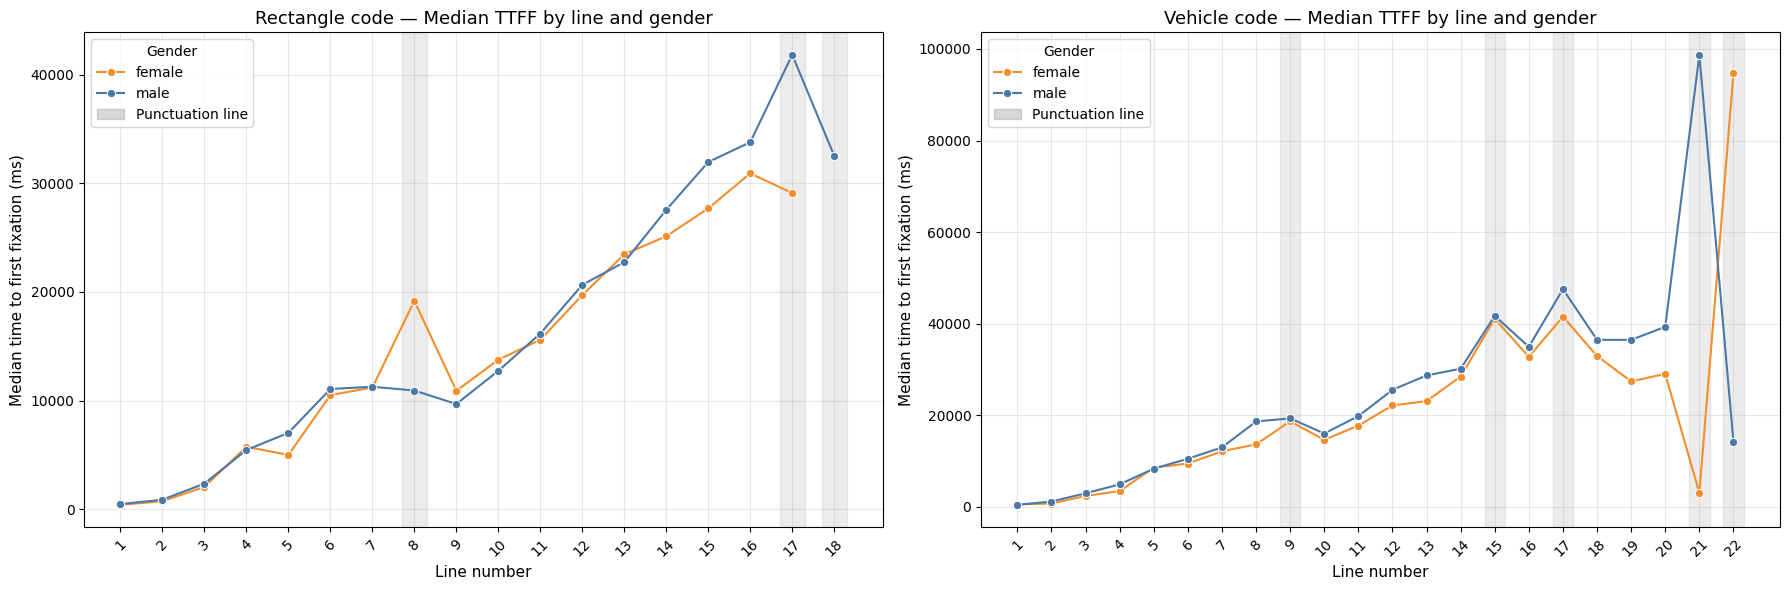

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Known punctuation lines per task
punctuation = {
    'vehicle': [9, 15, 17, 21, 22],
    'rectangle': [8, 17, 18]
}

# Build TTFF plot dataframe
ttff_plot_df = (
    line_metrics
    .dropna(subset=['ttff_ms'])
    .groupby(['task', 'gender', 'line_number'])
    .agg(median_ttff=('ttff_ms', 'median'))
    .reset_index()
)

# Token lookup for x axis
token_lookup = line_metrics[['task', 'line_number', 'aoi_token']].drop_duplicates()
token_lookup = token_lookup.sort_values(['task', 'line_number'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, task_name in zip(axes, ['rectangle', 'vehicle']):
    task_data = ttff_plot_df[ttff_plot_df['task'] == task_name]
    task_tokens = token_lookup[token_lookup['task'] == task_name]


    sns.lineplot(
        data=task_data,
        x='line_number',
        y='median_ttff',
        hue='gender',
        marker='o',
        palette=colors,
        ax=ax
    )

    # Shade punctuation lines
    for punc_line in punctuation[task_name]:
        ax.axvspan(punc_line - 0.3, punc_line + 0.3,
                   alpha=0.15, color='gray', label='_nolegend_')

    ax.set_title(f'{task_name.capitalize()} code â€” Median TTFF by line and gender',
                 fontsize=13)
    ax.set_xlabel('Line number', fontsize=11)
    ax.set_ylabel('Median time to first fixation (ms)', fontsize=11)
    ax.set_xticks(task_tokens['line_number'])
    ax.set_xticklabels(task_tokens['line_number'], rotation=45)
    ax.grid(True, alpha=0.3)

    # Add punctuation to legend
    punc_patch = mpatches.Patch(color='gray', alpha=0.3, label='Punctuation line')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [punc_patch],
              labels=labels + ['Punctuation line'],
              title='Gender')

plt.tight_layout()
plt.savefig('rq3_ttff_by_line.png', dpi=150, bbox_inches='tight')
plt.show()

- For both code stimuli, median time to first fixation increased monotonically with line number for male and female participants, indicating a largely topâ€‘toâ€‘bottom reading order. This pattern was consistent across genders, with no evidence of radically different navigation strategies.

- Pronounced TTFF peaks were observed near the end of the Vehicle code for both genders.

- The TTFF plots suggest that male and female participants follow broadly similar sequential reading strategies during code comprehension.

- The opposing TTFF patterns observed on the two closing brace lines likely reflect differences in when participants first reached the end of the code. Given the proximity of these lines, the pattern suggests that participants may have visited the end of the code more than once, for example during an initial structural scan and again upon completion of reading.

- The reversed ordering of these visits across genders may indicate subtle differences in progression timing rather than differences in reading order or comprehension strategy.

**Line dwell time per line - Effort**

In [109]:
effort_plot_df = (
    line_metrics
    .groupby(['task', 'gender', 'line_number'])
    .agg(median_line_dwell_time=('line_dwell_time', 'median'))
    .reset_index()
)


In [110]:
display(effort_plot_df)

,task,gender,line_number,median_line_dwell_time
0,rectangle,female,1,1525.6715
1,rectangle,female,2,2279.7360
2,rectangle,female,3,2071.8720
3,rectangle,female,4,943.7770
4,rectangle,female,5,828.4410
...,...,...,...,...
74,vehicle,male,18,1417.8490
75,vehicle,male,19,2589.9450
76,vehicle,male,20,1261.8780
77,vehicle,male,21,140.0220


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Known punctuation lines per task
punctuation = {
    'vehicle': [9, 15, 17, 21, 22],
    'rectangle': [8, 17, 18]
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, task_name in zip(axes, ['rectangle', 'vehicle']):
    task_data = effort_plot_df[effort_plot_df['task'] == task_name]

    sns.lineplot(
        data=task_data,
        x='line_number',
        y='median_line_dwell_time',
        hue='gender',
        marker='o',
        palette=colors,
        ax=ax
    )

    # Shade punctuation lines
    for punc_line in punctuation[task_name]:
        ax.axvspan(punc_line - 0.3, punc_line + 0.3,
                   alpha=0.15, color='gray', label='_nolegend_')

    # Get all line numbers for this task
    all_lines = sorted(task_data['line_number'].unique())

    ax.set_title(f'{task_name.capitalize()} code â€” Median line dwell time by line and gender',
                 fontsize=13)
    ax.set_xlabel('Line number', fontsize=11)
    ax.set_ylabel('Median line dwell time (ms)', fontsize=11)
    ax.set_xticks(all_lines)
    ax.set_xticklabels(all_lines, rotation=45)
    ax.grid(True, alpha=0.3)

    # Add punctuation annotation to legend
    punc_patch = mpatches.Patch(color='gray', alpha=0.3, label='Punctuation line')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [punc_patch],
              labels=labels + ['Punctuation line'],
              title='Gender')

plt.tight_layout()
plt.savefig('rq3_attention_profile.png', dpi=150, bbox_inches='tight')
plt.show()

- Median line dwell time varied substantially across line numbers for both code stimuli, with clear peaks at specific lines.

- These peaks were largely shared between male and female participants, indicating that the same lines attracted increased processing effort across genders.

- In both tasks, male participants tended to exhibit slightly higher median line dwell times on several lines (also confirmed by results of RQ2), although the overall shape of the effort distribution was similar for both genders.

- These results suggest that cognitive effort during code comprehension is concentrated on structurally or semantically demanding lines, and that male and female participants largely agree on which lines require deeper processing.

- The slightly higher line dwell times observed for male participants on some lines may reflect more prolonged inspection or verification

-  The similarity in effort profiles supports the interpretation that gender differences in overall effort (RQ2) are decomposed in RQ3 into subtle differences in degree or magnitude of effort rather than location of effort.

**Revisits**

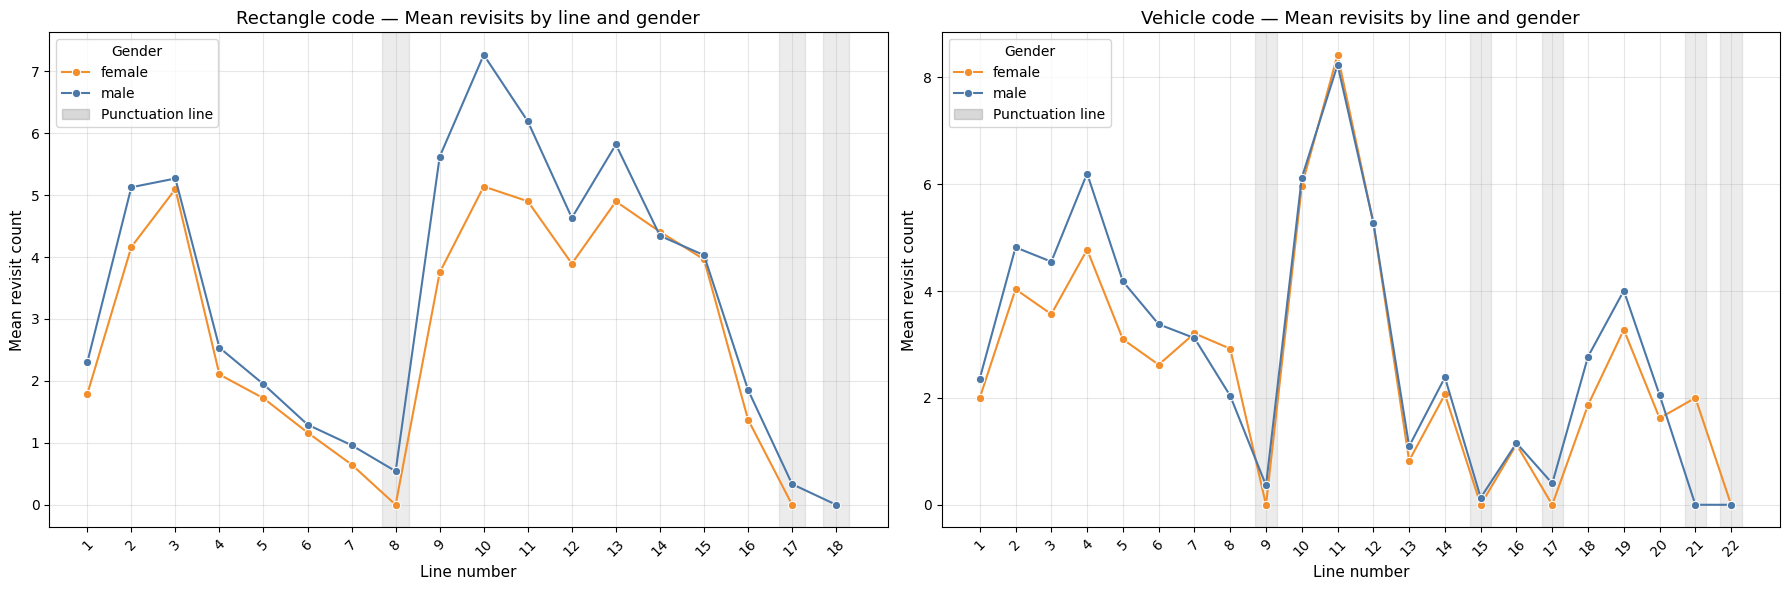

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Known punctuation lines per task
punctuation = {
    'vehicle': [9, 15, 17, 21, 22],
    'rectangle': [8, 17, 18]
}

# Build revisits plot dataframe
revisit_plot_df = (
    line_metrics
    .groupby(['task', 'gender', 'line_number'])
    .agg(mean_revisits=('revisits', 'mean'))
    .reset_index()
)

# Token lookup for x axis
token_lookup = line_metrics[['task', 'line_number', 'aoi_token']].drop_duplicates()
token_lookup = token_lookup.sort_values(['task', 'line_number'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, task_name in zip(axes, ['rectangle', 'vehicle']):
    task_data = revisit_plot_df[revisit_plot_df['task'] == task_name]
    task_tokens = token_lookup[token_lookup['task'] == task_name]

    sns.lineplot(
        data=task_data,
        x='line_number',
        y='mean_revisits',
        hue='gender',
        marker='o',
        palette=colors,
        ax=ax
    )

    # Shade punctuation lines
    for punc_line in punctuation[task_name]:
        ax.axvspan(punc_line - 0.3, punc_line + 0.3,
                   alpha=0.15, color='gray', label='_nolegend_')

    ax.set_title(f'{task_name.capitalize()} code â€” Mean revisits by line and gender',
                 fontsize=13)
    ax.set_xlabel('Line number', fontsize=11)
    ax.set_ylabel('Mean revisit count', fontsize=11)
    ax.set_xticks(task_tokens['line_number'])
    ax.set_xticklabels(task_tokens['line_number'], rotation=45)
    ax.grid(True, alpha=0.3)

    # Add punctuation to legend
    punc_patch = mpatches.Patch(color='gray', alpha=0.3, label='Punctuation line')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [punc_patch],
              labels=labels + ['Punctuation line'],
              title='Gender')

plt.tight_layout()
plt.savefig('rq3_revisits_by_line.png', dpi=150, bbox_inches='tight')
plt.show()

- Revisit frequency varied across line numbers for both code stimuli, with distinct peaks indicating lines that were frequently revisited after initial inspection.

- These peaks occurred at similar locations for male and female participants, particularly in the Vehicle code, where a prominent revisit peak was observed around the same line for both genders.

- Male participants exhibited slightly higher revisit frequencies on some lines, although overall revisit patterns appear similar.

- The slightly higher revisit rates observed for male participants suggest that extended engagement with earlier code regions involves additional regressions.

**Coverage**

In [113]:
display(coverage_df)

,participant_id,gender,expertise_programming_num,task_order,line_number,task,fixation_count,covered
0,2,male,2,2,1,vehicle,NaN,0
1,2,male,2,2,2,vehicle,6.0,1
2,2,male,2,2,3,vehicle,3.0,1
3,2,male,2,2,4,vehicle,16.0,1
4,2,male,2,2,5,vehicle,10.0,1
...,...,...,...,...,...,...,...,...
7155,216,female,0,2,14,rectangle,NaN,0
7156,216,female,0,2,15,rectangle,NaN,0
7157,216,female,0,2,16,rectangle,NaN,0
7158,216,female,0,2,17,rectangle,NaN,0


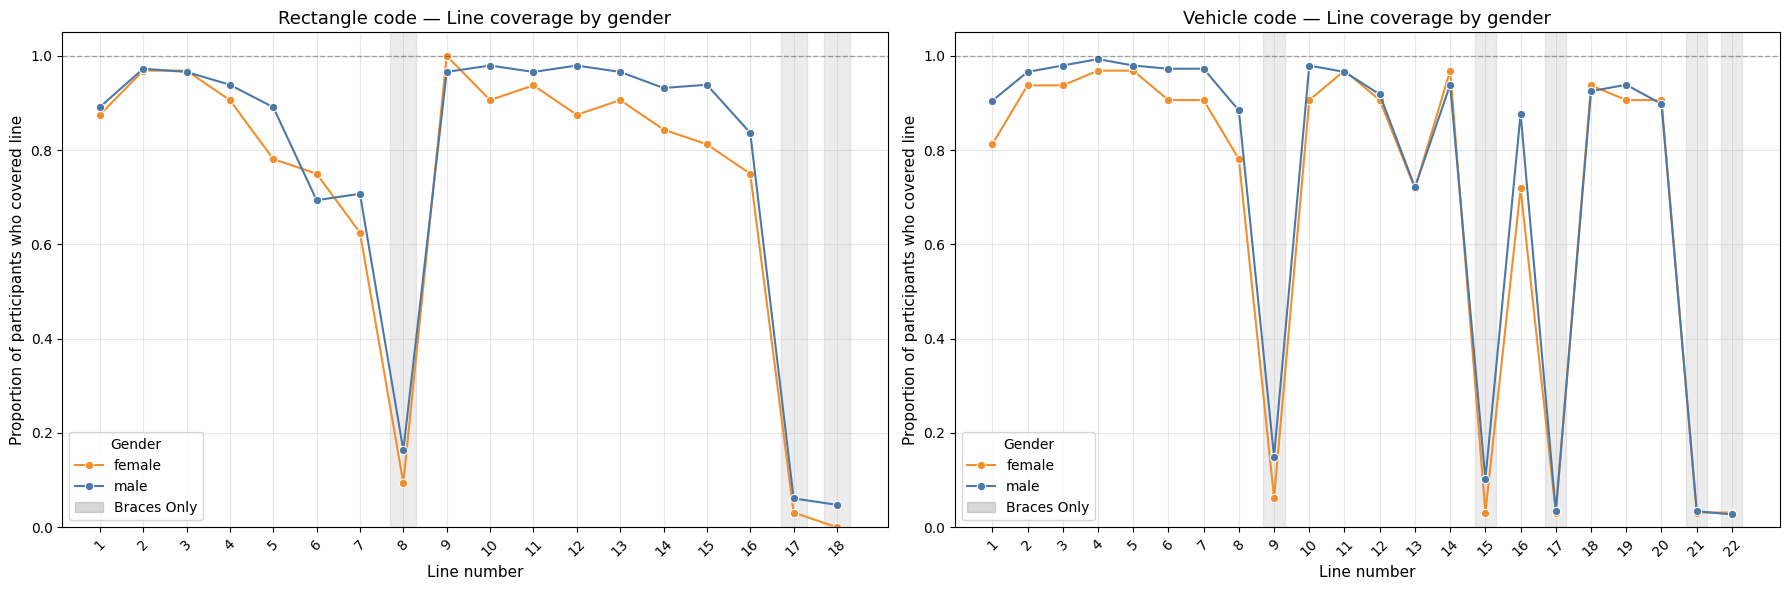

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Known punctuation lines per task
punctuation = {
    'vehicle': [9, 15, 17, 21, 22],
    'rectangle': [8, 17, 18]
}

# Build coverage plot dataframe
coverage_plot_df = (
    coverage_df
    .groupby(['task', 'gender', 'line_number'])
    .agg(p_covered=('covered', 'mean'))
    .reset_index()
)

# Token lookup for x axis
token_lookup = line_metrics[['task', 'line_number', 'aoi_token']].drop_duplicates()
token_lookup = token_lookup.sort_values(['task', 'line_number'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, task_name in zip(axes, ['rectangle', 'vehicle']):
    task_data = coverage_plot_df[coverage_plot_df['task'] == task_name]
    task_tokens = token_lookup[token_lookup['task'] == task_name]

    sns.lineplot(
        data=task_data,
        x='line_number',
        y='p_covered',
        hue='gender',
        marker='o',
        palette=colors,
        ax=ax
    )

    # Shade punctuation lines
    for punc_line in punctuation[task_name]:
        ax.axvspan(punc_line - 0.3, punc_line + 0.3,
                   alpha=0.15, color='gray', label='_nolegend_')

    # Reference line at 100% coverage
    ax.axhline(y=1.0, color='black', linestyle='--',
               alpha=0.3, linewidth=1, label='_nolegend_')

    ax.set_title(f'{task_name.capitalize()} code â€” Line coverage by gender',
                 fontsize=13)
    ax.set_xlabel('Line number', fontsize=11)
    ax.set_ylabel('Proportion of participants who covered line', fontsize=11)
    ax.set_xticks(task_tokens['line_number'])
    ax.set_xticklabels(task_tokens['line_number'], rotation=45)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # Add punctuation to legend
    punc_patch = mpatches.Patch(color='gray', alpha=0.3, label='Punctuation line')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [punc_patch],
              labels=labels + ['Braces Only'],
              title='Gender')

plt.tight_layout()
plt.savefig('rq3_coverage_by_line.png', dpi=150, bbox_inches='tight')
plt.show()

- Across both code stimuli, line coverage was generally high for both male and female participants, indicating that most lines were fixated by a majority of readers

- Sharp reductions in line coverage were observed exclusively on braceâ€‘only lines in both code stimuli.

- As these lines contain no semantic content, reduced fixation probability likely reflects strategic skipping of structural punctuation rather than incomplete reading.

- Coverage patterns were highly similar across genders, indicating shared structural reading strategies. The similarity between male and female coverage profiles suggests that both groups prioritised the same regions of the code for initial attention

# Interactive plots

In [115]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Build hover data â€” merge token into plot dataframe
token_lookup = line_metrics[['task', 'line_number', 'aoi_token']].drop_duplicates()

ttff_plot_df = ttff_plot_df.merge(token_lookup, on=['task', 'line_number'], how='left')
effort_plot_df = effort_plot_df.merge(token_lookup, on=['task', 'line_number'], how='left')
revisit_plot_df = revisit_plot_df.merge(token_lookup, on=['task', 'line_number'], how='left')
coverage_plot_df = coverage_plot_df.merge(token_lookup, on=['task', 'line_number'], how='left')

# Punctuation lines
punctuation = {
    'vehicle': [9, 15, 17, 21, 22],
    'rectangle': [8, 17, 18]
}


def make_interactive_plot(plot_df, y_col, y_label, title_prefix):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            f'Rectangle code â€” {title_prefix}',
            f'Vehicle code â€” {title_prefix}'
        ]
    )

    for col_idx, task_name in enumerate(['rectangle', 'vehicle'], start=1):
        task_data = plot_df[plot_df['task'] == task_name]

        for gender in ['male', 'female']:
            gender_data = task_data[task_data['gender'] == gender].sort_values('line_number')

            fig.add_trace(
                go.Scatter(
                    x=gender_data['line_number'],
                    y=gender_data[y_col],
                    mode='lines+markers',
                    name=gender,
                    legendgroup=gender,
                    showlegend=(col_idx == 1),
                    line=dict(color=colors[gender]),
                    marker=dict(size=8),
                    customdata=gender_data['aoi_token'],
                    hovertemplate=(
                        f'<b>Line %{{x}}</b><br>'
                        f'Gender: {gender}<br>'
                        f'{y_label}: %{{y:.1f}}<br>'
                        f'Token: %{{customdata}}<extra></extra>'
                    )
                ),
                row=1, col=col_idx
            )

        # Add punctuation shading
        for punc_line in punctuation[task_name]:
            fig.add_vrect(
                x0=punc_line - 0.3, x1=punc_line + 0.3,
                fillcolor='gray', opacity=0.15,
                layer='below', line_width=0,
                row=1, col=col_idx
            )

    fig.update_layout(
        height=500,
        width=1200,
        title_text=f'{title_prefix} by line and gender',
        hovermode='x unified'
    )
    fig.update_xaxes(title_text='Line number', dtick=1)
    fig.update_yaxes(title_text=y_label)

    return fig

# Generate all four plots
fig_ttff = make_interactive_plot(ttff_plot_df, 'median_ttff',
                                  'Median TTFF (ms)', 'Median TTFF')
fig_effort = make_interactive_plot(effort_plot_df, 'median_line_dwell_time',
                                    'Median line dwell time (ms)', 'Median line dwell time')
fig_revisits = make_interactive_plot(revisit_plot_df, 'mean_revisits',
                                      'Mean revisits', 'Mean revisits')
fig_coverage = make_interactive_plot(coverage_plot_df, 'p_covered',
                                      'Proportion covered', 'Line coverage')

# Show all four
fig_ttff.show()
fig_effort.show()
fig_revisits.show()
fig_coverage.show()

# Statistics

In [116]:
import numpy as np

# Check skewness of all three outcome variables
for col in ['line_dwell_time', 'ttff_ms', 'revisits']:
    skew = line_metrics[col].skew()
    kurt = line_metrics[col].kurt()
    print(f"{col}: skewness={skew:.3f}, kurtosis={kurt:.3f}")

line_dwell_time: skewness=3.578, kurtosis=27.354
ttff_ms: skewness=1.804, kurtosis=5.600
revisits: skewness=3.019, kurtosis=21.792


In [117]:
print("\nRevisits distribution:")
print(line_metrics['revisits'].describe())
print("\nHow many zeros:", (line_metrics['revisits'] == 0).sum())
print("Proportion zeros:", (line_metrics['revisits'] == 0).mean().round(3))



Revisits distribution:
count    5327.000000
mean        3.795757
std         4.361263
min         0.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        72.000000
Name: revisits, dtype: float64

How many zeros: 1008
Proportion zeros: 0.189


In [118]:
# Log transformations
line_metrics['log_line_dwell_time'] = np.log(line_metrics['line_dwell_time'])
line_metrics['log_ttff'] = np.log1p(line_metrics['ttff_ms'])
#line_metrics['log_revisits'] = np.log1p(line_metrics['revisits'])  # +1 for zeros

#drop column log_visits
#line_metrics = line_metrics.drop(columns=['log_revisits'])

line_metrics['revisited'] = (line_metrics['revisits'] > 0).astype(int)


# Verify transformations
for col in ['log_line_dwell_time', 'log_ttff']:
    skew = line_metrics[col].skew()
    kurt = line_metrics[col].kurt()
    print(f"{col}: skewness={skew:.3f}, kurtosis={kurt:.3f}")

log_line_dwell_time: skewness=-0.406, kurtosis=-0.264
log_ttff: skewness=-2.204, kurtosis=6.135


In [119]:
display(line_metrics)

,participant_id,gender,task,line_number,line_type,aoi_token,line_dwell_time,fixation_count,ttff_ms,revisits,expertise_programming_num,task_order,log_line_dwell_time,log_ttff,revisited
0,2,male,rectangle,1,semantic,public class Rectangle {,1347.940,10,1231.862,2,2,1,7.206333,7.117094,1
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",2679.688,16,2043.877,1,2,1,7.893456,7.623093,1
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",319.889,3,9007.333,2,2,1,5.767974,9.105905,1
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,1203.848,7,9299.412,2,2,1,7.093278,9.137814,1
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,652.065,4,10483.230,1,2,1,6.480144,9.257628,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,767.856,6,40484.368,1,0,1,6.643602,10.608696,1
5323,216,female,vehicle,17,punctuation,},256.193,2,41539.715,0,0,1,5.545931,10.634429,0
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,955.841,7,67214.075,0,0,1,6.862592,11.115653,0
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",124.080,1,70749.577,0,0,1,4.820927,11.166916,0


Distributional diagnostics revealed substantial right skew and heavy tails for raw line dwell time and TTFF measures.

Logâ€‘transformation resulted in approximately symmetric line dwell time distributions and acceptable TTFF distributions for mixedâ€‘effects modelling.

Revisits were modelled as a binary outcome reflecting whether a line was reâ€‘examined.

Line coverage was also modelled as a binary outcome, as it represents whether a line was fixated at all, with reduced coverage occurring on braceâ€‘only lines.

In [120]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

lmm_df = line_metrics.copy()

# Ensure categorical variables are correctly specified
lmm_df['task'] = lmm_df['task'].astype('category')
lmm_df['task'] = lmm_df['task'].cat.reorder_categories(
    ['rectangle', 'vehicle'], ordered=True
)

lmm_df['gender'] = lmm_df['gender'].astype('category')
lmm_df['participant_id'] = lmm_df['participant_id'].astype('category')
lmm_df['task_order'] = lmm_df['task_order'].astype('category')
lmm_df['task_order'] = lmm_df['task_order'].cat.reorder_categories(
    [1, 2], ordered=False
)


In [121]:
display(lmm_df)

,participant_id,gender,task,line_number,line_type,aoi_token,line_dwell_time,fixation_count,ttff_ms,revisits,expertise_programming_num,task_order,log_line_dwell_time,log_ttff,revisited
0,2,male,rectangle,1,semantic,public class Rectangle {,1347.940,10,1231.862,2,2,1,7.206333,7.117094,1
1,2,male,rectangle,2,semantic,"private int x1 , y1 , x2 , y2 ;",2679.688,16,2043.877,1,2,1,7.893456,7.623093,1
2,2,male,rectangle,3,semantic,"public Rectangle ( int x1 , int y1 , int x2 , ...",319.889,3,9007.333,2,2,1,5.767974,9.105905,1
3,2,male,rectangle,4,semantic,this.x1 = x1 ;,1203.848,7,9299.412,2,2,1,7.093278,9.137814,1
4,2,male,rectangle,5,semantic,this.y1 = y1 ;,652.065,4,10483.230,1,2,1,6.480144,9.257628,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,216,female,vehicle,16,semantic,return this.currentSpeed ;,767.856,6,40484.368,1,0,1,6.643602,10.608696,1
5323,216,female,vehicle,17,punctuation,},256.193,2,41539.715,0,0,1,5.545931,10.634429,0
5324,216,female,vehicle,18,semantic,public static void main ( String args [ ] ) {,955.841,7,67214.075,0,0,1,6.862592,11.115653,0
5325,216,female,vehicle,19,semantic,"Vehicle v = new Vehicle ( ""Audi"" , ""A6"" , 200 ) ;",124.080,1,70749.577,0,0,1,4.820927,11.166916,0


**Line dwell time**

In [122]:
lmm_df["line_length"] = (
   lmm_df["aoi_token"].str.len()
)
lmm_df["line_length_c"] = lmm_df["line_length"] - lmm_df["line_length"].mean()

# normalize line position
lmm_df["line_position"] = (
    lmm_df.groupby("task")["line_number"]
    .transform(lambda x: x / x.max())
)

# center it
lmm_df["line_position_c"] = (
    lmm_df["line_position"] - lmm_df["line_position"].mean()
)



fix_model = smf.mixedlm(
    "log_line_dwell_time ~ gender * task + line_position_c + line_length_c + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"],
    re_formula="~line_position_c"
)
fix_result = fix_model.fit(method="lbfgs")
print(fix_result.summary())


/tmp/ipykernel_1963/2762879818.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      log_line_dwell_time
No. Observations:       5327         Method:                  REML        
No. Groups:             179          Scale:                   0.7000      
Min. group size:        9            Log-Likelihood:          -6900.3841  
Max. group size:        35           Converged:               Yes         
Mean group size:        29.8                                              
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       6.900    0.113  60.877 0.000  6.678  7.122
gender[T.male]                  0.289    0.102   2.824 0.005  0.088  0.489
task[T.vehicle]                 0.318    0.056   5.645 0.000  0.208  0.428
task_order[T.2]                -0.040

Male participants showed higher line dwell time than female participants after controlling for line position, line length, programming expertise, task, task order, and participant-level variation (beta = 0.289, p = .005). Because the outcome is log-transformed, this corresponds to approximately 33.5% higher line dwell time.

The Vehicle task also elicited higher line dwell time than Rectangle (beta = 0.318, p < .001), corresponding to approximately 37.4% higher line dwell time. The gender x task interaction was marginal but non-significant (beta = -0.106, p = .085), so the model does not provide reliable evidence that the gender difference changed by task.

Line dwell time decreased later in the code and increased with line length. Programming expertise was not a significant predictor once source-line structure and task variables were controlled (p = .371), and task order was marginal but non-significant (p = .086).

**TTFF (Reading order)**

TTFF was modelled using linear mixedâ€‘effects models with logâ€‘transformed outcomes, including relative line position to capture progression through the code. Line length was not included, as TTFF reflects arrival timing rather than processing effort.

In [123]:
ttff_model = smf.mixedlm(
    "log_ttff ~ gender * task + line_position_c + expertise_programming_num + task_order",
    data=lmm_df,
    groups=lmm_df["participant_id"],
    re_formula="~line_position_c"
)

ttff_result = ttff_model.fit(method="lbfgs")
print(ttff_result.summary())


                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      log_ttff   
No. Observations:       5327         Method:                  REML       
No. Groups:             179          Scale:                   2.7070     
Min. group size:        9            Log-Likelihood:          -10281.2414
Max. group size:        35           Converged:               Yes        
Mean group size:        29.8                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       8.675    0.117 74.448 0.000  8.447  8.903
gender[T.male]                  0.034    0.109  0.317 0.751 -0.179  0.248
task[T.vehicle]                 0.443    0.110  4.032 0.000  0.228  0.658
task_order[T.2]                 0.040    0.045  0.882 0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



The TTFF model converged, although the random slope for line position was effectively zero. Line position had a large significant effect on TTFF (p < .001): lines appearing later in the code were first fixated later, consistent with a broadly top-to-bottom inspection pattern.

Task was also significant (beta = 0.443, p < .001), indicating later first fixations in the Vehicle task than in Rectangle. Gender was not significant (beta = 0.034, p = .751), the gender x task interaction was not significant (p = .940), programming expertise was not significant (p = .677), and task order was not significant (p = .378).

Overall, TTFF was shaped by line position and task rather than by gender.

**Revisits**

â€œA generalized estimating equations (GEE) approach was used to account for within-participant correlations in the binary revisit outcome (in consistency with using GEE for RQ1 for binary outcomes)"

In [124]:
import statsmodels.api as sm

revisit_model = smf.gee(
    "revisited ~ gender * task + line_position_c + expertise_programming_num + task_order",
    groups="participant_id",
    data=lmm_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
)

revisit_result = revisit_model.fit()
print(revisit_result.summary())

                               GEE Regression Results                              
Dep. Variable:                   revisited   No. Observations:                 5327
Model:                                 GEE   No. clusters:                      179
Method:                        Generalized   Min. cluster size:                   9
                      Estimating Equations   Max. cluster size:                  35
Family:                           Binomial   Mean cluster size:                29.8
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Fri, 29 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         00:53:52
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.8411     

- Line position had a significant negative effect on revisits (p < .001).
Lines appearing later in the task were less likely to be revisited.

- Expertise significantly increased the likelihood of revisits (p = .003). More experienced participants were more likely to revisit lines.This suggests that experts may engage in deeper verification or strategic re-reading

- No significant main effect of gender (p = .250).

- No significant main effect of task (p = .332). The likelihood of revisiting lines did not differ substantially between tasks.

- Gender Ã— Task interaction was marginally non-significant (p = .096).
This suggests a possible trend that effect of task on revisits may differ slightly by gender (not strong enough to be statistically significant)


**Coverage**

â€œA generalized estimating equations (GEE) approach was fitted to predict whether a line was covered (fixated at least once) which is a binary outcome (consistent with using GEE for RQ1 for binary outcomes)"

In [125]:
coverage_df["covered"].value_counts(normalize=True)

,proportion
covered,
1,0.743994
0,0.256006


In [126]:
# normalize line position
coverage_df["line_position"] = (
    coverage_df.groupby("task")["line_number"]
    .transform(lambda x: x / x.max())
)

# center it
coverage_df["line_position_c"] = (
    coverage_df["line_position"] - coverage_df["line_position"].mean()
)

# Ensure categorical variables are correctly specified
coverage_df['task'] = coverage_df['task'].astype('category')
coverage_df['task'] = coverage_df['task'].cat.reorder_categories(
    ['rectangle', 'vehicle'], ordered=True
)

coverage_df['gender'] = coverage_df['gender'].astype('category')
coverage_df['participant_id'] = coverage_df['participant_id'].astype('category')
coverage_df['task_order'] = coverage_df['task_order'].astype('category')
coverage_df['task_order'] = coverage_df['task_order'].cat.reorder_categories(
    [1, 2], ordered=False
)

In [127]:
coverage_model = smf.gee(
    "covered ~ gender * task + line_position_c + expertise_programming_num + task_order",
    groups="participant_id",
    data=coverage_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
)

coverage_result = coverage_model.fit()
print(coverage_result.summary())

                               GEE Regression Results                              
Dep. Variable:                     covered   No. Observations:                 7160
Model:                                 GEE   No. clusters:                      179
Method:                        Generalized   Min. cluster size:                  40
                      Estimating Equations   Max. cluster size:                  40
Family:                           Binomial   Mean cluster size:                40.0
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Fri, 29 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         00:53:53
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.1847     

- Line position had a statistically significant negative effect (p < .001).
Lines appearing later in the task were substantially less likely to be covered.

- Gender showed a marginally non-significant effect (p = .067).
There is a trend suggesting males may be slightly more likely to cover lines, but this is not statistically conclusive.

- Task was not a significant predictor (p = .125). Coverage rates were similar across tasks.

- Gender Ã— Task interaction was not significant (p = .507). This indicates that task effects on coverage do not differ by gender.

- Programming expertise did not significantly affect coverage (p = .458).

- Task order was not significant (Î² = -0.054, p = .253). No evidence of learning or fatigue effects on coverage.